# Telecom Customer Attrition: Churn Classification and Risk Analysis.

### Project question

Can the customer attributes in this dataset distinguish records labeled as churned from records labeled as retained?

Machine-learning task

This is a supervised binary-classification task using Churn as the target:

0 = labeled as no churn

1 = labeled as churn

### ## Potential business use
If future documentation confirms that the customer attributes were recorded before churn, a validated model could help prioritize customers for review.

## Analysis objectives
1. Explore how customer attributes relate to the supplied churn label.
2. Compare models using metrics that reflect the smaller churn class.
3. Identify findings that could guide further investigation.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from pathlib import Path

candidate_paths = [
    Path("data/raw/telecom_churn.csv"),
    Path("../data/raw/telecom_churn.csv"),
]

csv_path = next(
    (path for path in candidate_paths if path.is_file()),
    None
)

if csv_path is None:
    checked_paths = "\n".join(str(path) for path in candidate_paths)
    raise FileNotFoundError(
        f"Dataset not found. Checked:\n{checked_paths}"
    )

PROJECT_ROOT = csv_path.resolve().parents[2]

df = pd.read_csv(csv_path)
print(f"Loaded dataset: {csv_path}")
print(f"Rows: {df.shape[0]:,} | Columns: {df.shape[1]}")

Loaded dataset: data/raw/telecom_churn.csv
Rows: 3,333 | Columns: 11


# Data Quality Audit

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3333 entries, 0 to 3332
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Churn            3333 non-null   int64  
 1   AccountWeeks     3333 non-null   int64  
 2   ContractRenewal  3333 non-null   int64  
 3   DataPlan         3333 non-null   int64  
 4   DataUsage        3333 non-null   float64
 5   CustServCalls    3333 non-null   int64  
 6   DayMins          3333 non-null   float64
 7   DayCalls         3333 non-null   int64  
 8   MonthlyCharge    3333 non-null   float64
 9   OverageFee       3333 non-null   float64
 10  RoamMins         3333 non-null   float64
dtypes: float64(5), int64(6)
memory usage: 286.6 KB


In [ ]:
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

Rows: 3333
Columns: 11


In [ ]:
df.sample(5, random_state=42)

,Churn,AccountWeeks,ContractRenewal,DataPlan,DataUsage,CustServCalls,DayMins,DayCalls,MonthlyCharge,OverageFee,RoamMins
438,0,113,1,0,0.00,1,155.0,93,55.0,16.53,13.5
2674,0,67,1,0,0.00,0,109.1,117,38.0,10.87,12.8
1345,1,98,1,0,0.00,4,0.0,0,14.0,7.98,6.8
1957,0,147,1,0,0.33,1,212.8,79,57.3,10.21,10.2
2148,0,96,1,0,0.30,1,144.0,102,47.0,11.24,10.0


every time you run: df.sample(5) --> you may get different customers.


With:

random_state=42

you get the same sample each time.

This is exactly the kind of small detail that contributes to reproducibility.

In [ ]:
print("Dataset shape:", df.shape)

Dataset shape: (3333, 11)


That means:
- 3,333 rows → customers
- 11 columns → customer attributes + target

In [ ]:
df.dtypes

,0
Churn,int64
AccountWeeks,int64
ContractRenewal,int64
DataPlan,int64
DataUsage,float64
CustServCalls,int64
DayMins,float64
DayCalls,int64
MonthlyCharge,float64
OverageFee,float64


In [ ]:
df.dtypes.value_counts()

,count
int64,6
float64,5


In [ ]:
df.isnull().sum()

,0
Churn,0
AccountWeeks,0
ContractRenewal,0
DataPlan,0
DataUsage,0
CustServCalls,0
DayMins,0
DayCalls,0
MonthlyCharge,0
OverageFee,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
# check unique values

unique_summary = df.nunique().rename("Unique_Values").to_frame()

unique_summary

,Unique_Values
Churn,2
AccountWeeks,212
ContractRenewal,2
DataPlan,2
DataUsage,174
CustServCalls,10
DayMins,1667
DayCalls,119
MonthlyCharge,627
OverageFee,1024


In [ ]:
# Identify binary variables

binary_columns = [
    col for col in df.columns
    if df[col].nunique() == 2
]

binary_columns

['Churn', 'ContractRenewal', 'DataPlan']

In [ ]:
# now inspect their actual values

for col in binary_columns:
    print(f"\n{col}")
    print(df[col].value_counts().sort_index())



Churn
Churn
0    2850
1     483
Name: count, dtype: int64

ContractRenewal
ContractRenewal
0     323
1    3010
Name: count, dtype: int64

DataPlan
DataPlan
0    2411
1     922
Name: count, dtype: int64


In [ ]:
# Validate binary variables : (Let's explicitly check that the binary columns contain only expected values.)

for col in ["ContractRenewal", "DataPlan", "Churn"]:
    print(f"{col}: {sorted(df[col].unique())}")

ContractRenewal: [np.int64(0), np.int64(1)]
DataPlan: [np.int64(0), np.int64(1)]
Churn: [np.int64(0), np.int64(1)]


In [ ]:
# Check the Target Variable

churn_summary = pd.DataFrame({
    "Count": df["Churn"].value_counts(),
    "Percentage": df["Churn"].value_counts(normalize=True) * 100
})

churn_summary

,Count,Percentage
Churn,,
0,2850,85.508551
1,483,14.491449


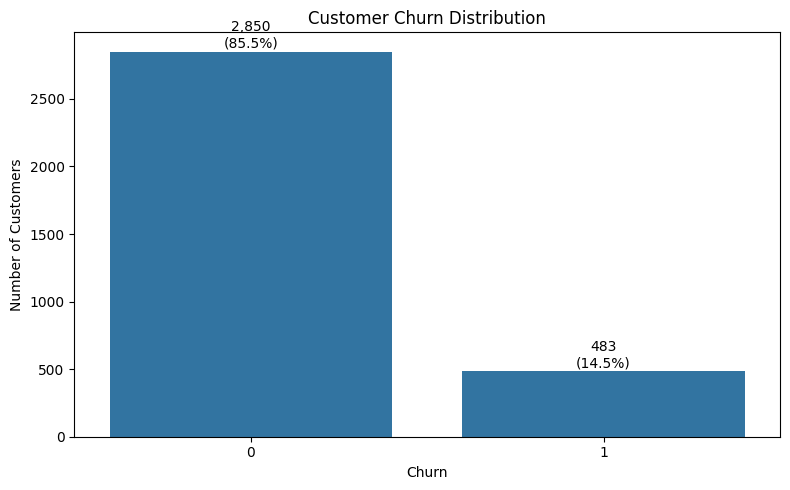

In [ ]:
# Create Chart for Target Distribution

churn_counts = df["Churn"].value_counts().sort_index()
churn_percentages = df["Churn"].value_counts(normalize=True).sort_index() * 100

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    x=churn_counts.index,
    y=churn_counts.values
)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

for i, (count, percentage) in enumerate(
    zip(churn_counts.values, churn_percentages.values)
):
    ax.text(
        i,
        count + 30,
        f"{count:,}\n({percentage:.1f}%)",
        ha="center"
    )

plt.tight_layout()
plt.show()

**Target Variable Distribution**

The dataset contains 3,333 customers, of which 2,850 (85.5%) did not churn and 483 (14.5%) churned.

This indicates that churn is the minority class in the dataset, with approximately one out of every seven customers represented as a churned customer.

The target distribution is therefore imbalanced. This is important for the predictive modeling stage because a model could achieve relatively high overall accuracy by favoring the majority class while failing to identify a meaningful proportion of churned customers.

Because churn is the minority class, model evaluation will include precision, recall, F1-score, ROC-AUC, and Average Precision (AP), rather than accuracy alone.

In [ ]:
# Check numerical variables

numerical_columns = [
    col for col in df.select_dtypes(include="number").columns
    if col not in binary_columns
]

numerical_columns



['AccountWeeks',
 'DataUsage',
 'CustServCalls',
 'DayMins',
 'DayCalls',
 'MonthlyCharge',
 'OverageFee',
 'RoamMins']

In [ ]:
df[numerical_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
AccountWeeks,3333.0,101.064806,39.822106,1.0,74.00,101.00,127.00,243.00
DataUsage,3333.0,0.816475,1.272668,0.0,0.00,0.00,1.78,5.40
CustServCalls,3333.0,1.562856,1.315491,0.0,1.00,1.00,2.00,9.00
DayMins,3333.0,179.775098,54.467389,0.0,143.70,179.40,216.40,350.80
DayCalls,3333.0,100.435644,20.069084,0.0,87.00,101.00,114.00,165.00
MonthlyCharge,3333.0,56.305161,16.426032,14.0,45.00,53.50,66.20,111.30
OverageFee,3333.0,10.051488,2.535712,0.0,8.33,10.07,11.77,18.19
RoamMins,3333.0,10.237294,2.791840,0.0,8.50,10.30,12.10,20.00


In [ ]:
#  Check that non-negative measures contain no negative values. : (Some variables should logically not be negative.)

non_negative_columns = [
    "AccountWeeks",
    "DataUsage",
    "CustServCalls",
    "DayMins",
    "DayCalls",
    "MonthlyCharge",
    "OverageFee",
    "RoamMins"
]

negative_values = (df[non_negative_columns] < 0).sum()

negative_values


,0
AccountWeeks,0
DataUsage,0
CustServCalls,0
DayMins,0
DayCalls,0
MonthlyCharge,0
OverageFee,0
RoamMins,0


In [ ]:
# Check for suspicious constant columns : (A constant column contains the same value for every customer.Such a column provides no predictive information.)

constant_columns = [
    col for col in df.columns
    if df[col].nunique() <= 1
]

print("Constant columns:", constant_columns)

Constant columns: []


# Exploratory Data Analysis

## Objective

This section explores feature distributions and their associations with the supplied Churn label. The analysis is descriptive; it does not establish causation or future-prediction performance.

The analysis will focus on:

- Customer tenure
- Contract renewal behavior
- Data-plan adoption
- Customer service interactions
- Call and data usage
- Monthly charges and overage fees
- Roaming usage
- Differences between churned and retained customers

EDA findings will be used to inform feature preprocessing, model selection, evaluation, and business interpretation.

In [ ]:
# Identify variable types : (We already know the binary variables, but let's formally create the groups.)

binary_features = [
    col for col in binary_columns
    if col != "Churn"
]

numerical_features = numerical_columns


**Univariate analysis** —  numerical variables

Univariate analysis means:
Study one variable at a time.

Before asking what causes churn, we first need to understand what the variables themselves look like.

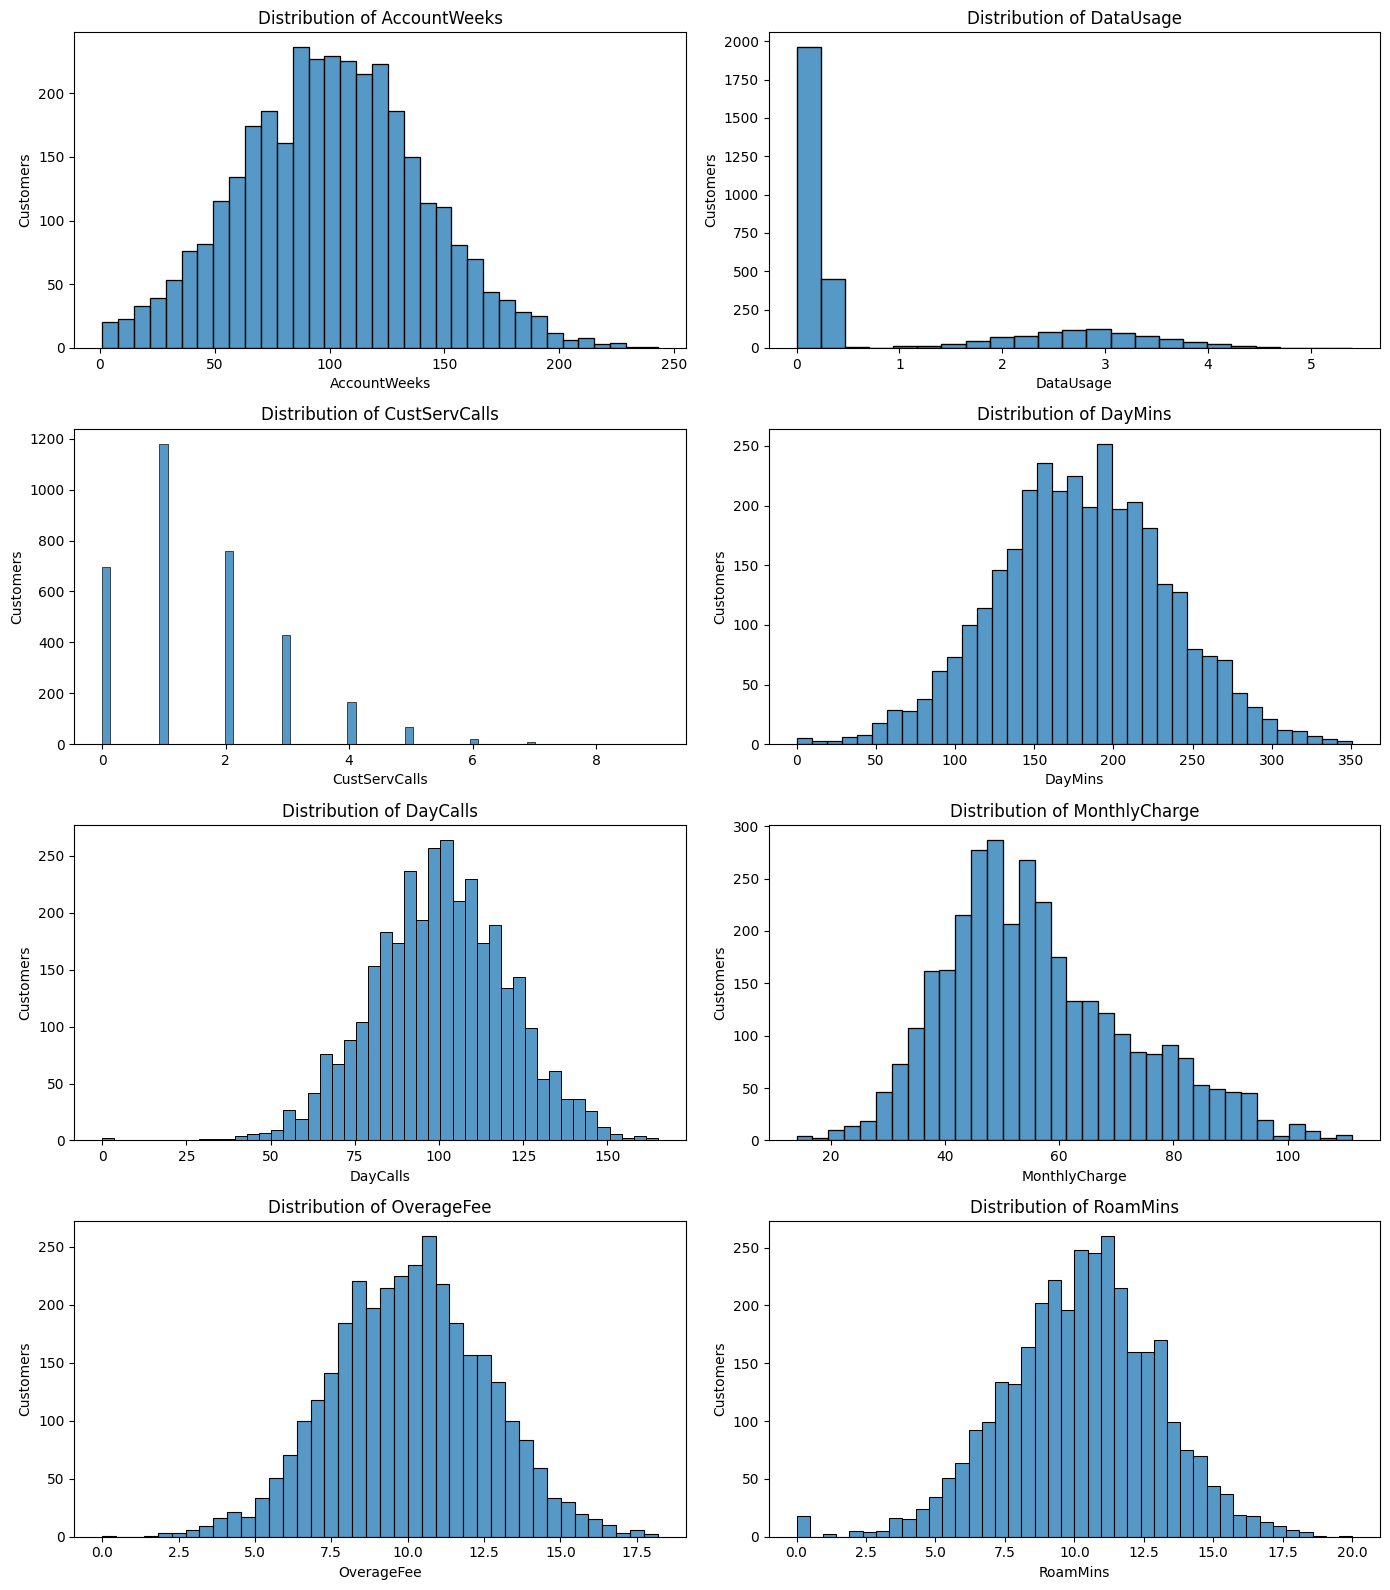

In [ ]:
# Numerical distributions

fig, axes = plt.subplots(
    nrows=4,
    ncols=2,
    figsize=(14, 16)
)

for ax, column in zip(axes.flatten(), numerical_features):
    sns.histplot(
        data=df,
        x=column,
        kde=False,
        ax=ax
    )

    ax.set_title(f"Distribution of {column}")
    ax.set_xlabel(column)
    ax.set_ylabel("Customers")

plt.tight_layout()
plt.show()

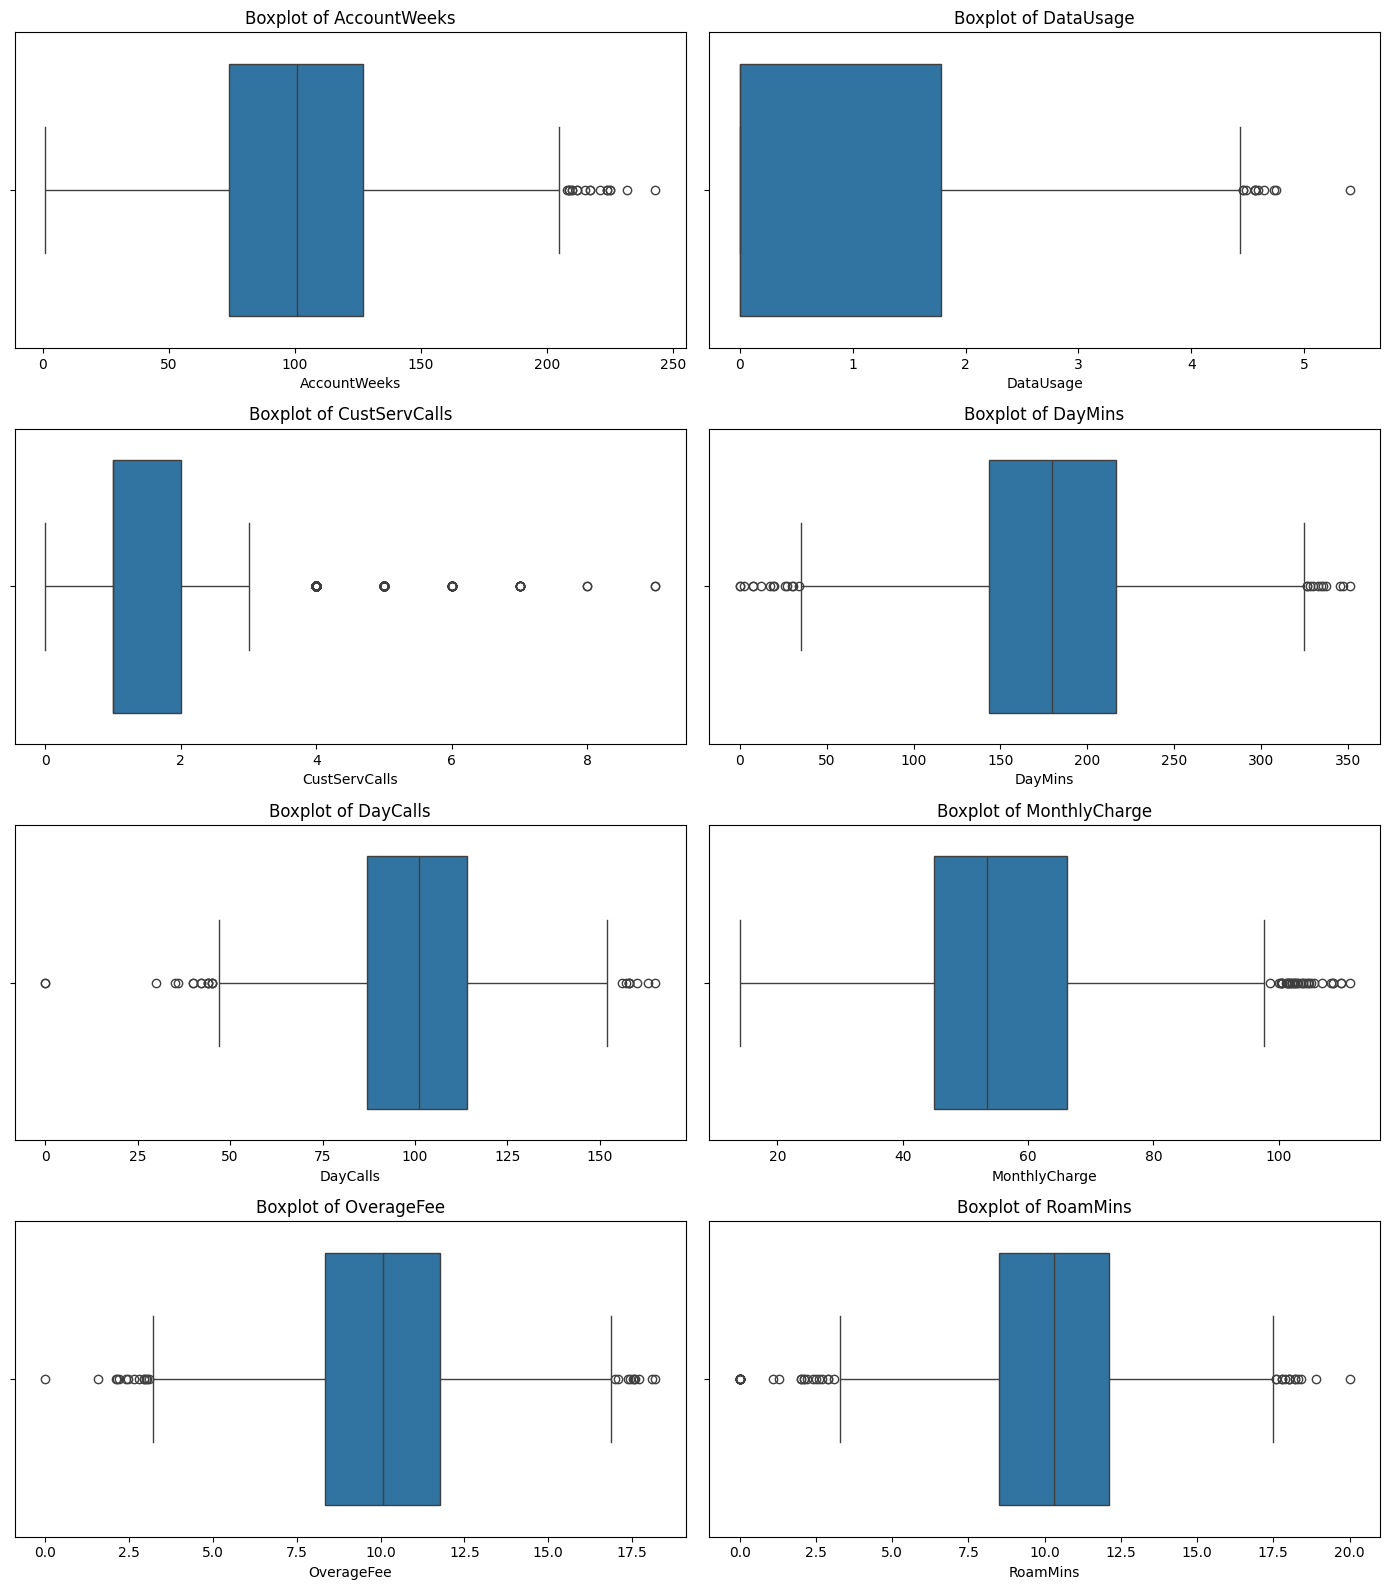

In [ ]:
# Boxplots for numerical variables
# Histograms show distribution. Boxplots are particularly useful for identifying potential outliers.

fig, axes = plt.subplots(
    nrows=4,
    ncols=2,
    figsize=(14, 16)
)

for ax, column in zip(axes.flatten(), numerical_features):
    sns.boxplot(
        data=df,
        x=column,
        ax=ax
    )

    ax.set_title(f"Boxplot of {column}")
    ax.set_xlabel(column)

plt.tight_layout()
plt.show()

Univariate analysis — binary variables

Now let's examine:
- Contract renewal
- Data plan

This gives us the distribution of each binary feature.

In [ ]:
for column in binary_features:
    print(f"\n{column}")
    print(df[column].value_counts())
    print(
        (df[column].value_counts(normalize=True) * 100)
        .round(2)
    )


ContractRenewal
ContractRenewal
1    3010
0     323
Name: count, dtype: int64
ContractRenewal
1    90.31
0     9.69
Name: proportion, dtype: float64

DataPlan
DataPlan
0    2411
1     922
Name: count, dtype: int64
DataPlan
0    72.34
1    27.66
Name: proportion, dtype: float64


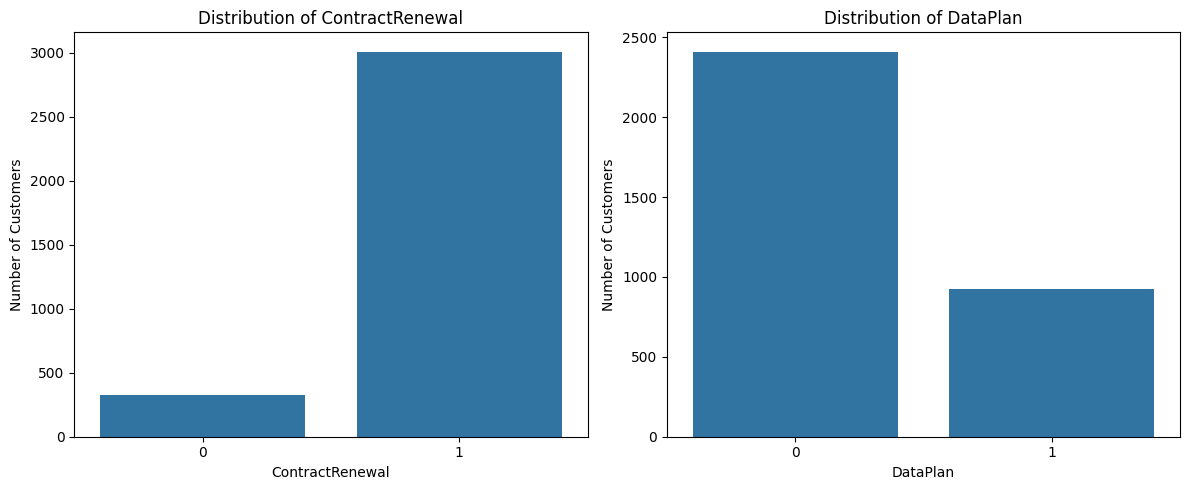

In [ ]:
# Visualize binary variables

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 5)
)

for ax, column in zip(axes, binary_features):
    sns.countplot(
        data=df,
        x=column,
        ax=ax
    )

    ax.set_title(f"Distribution of {column}")
    ax.set_xlabel(column)
    ax.set_ylabel("Number of Customers")

plt.tight_layout()
plt.show()

Now we move to the most important part:

Churn vs Customer Characteristics

We'll investigate whether churn rates differ across customer groups.

In [ ]:
# Churn rate by Contract Renewal

contract_churn = (
    df.groupby("ContractRenewal")["Churn"]
      .agg(Customers="count", Churn_Rate="mean")
      .reset_index()
)

contract_churn["Churn_Rate"] *= 100
contract_churn


,ContractRenewal,Customers,Churn_Rate
0,0,323,42.414861
1,1,3010,11.495017


Customers who did not renew their contracts have a substantially higher observed churn rate than customers who renewed their contracts. The difference is approximately 30.9 percentage points in this dataset. Contract renewal therefore appears to be an important variable for distinguishing churned and retained customers.

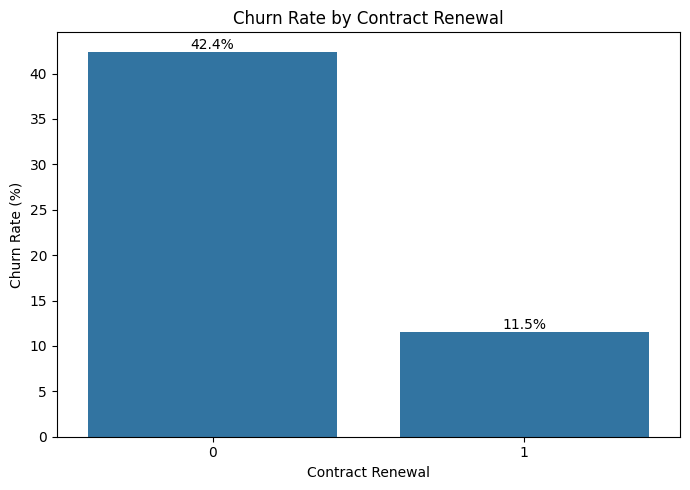

In [ ]:
plt.figure(figsize=(7, 5))

ax = sns.barplot(
    data=contract_churn,
    x="ContractRenewal",
    y="Churn_Rate"
)

plt.title("Churn Rate by Contract Renewal")
plt.xlabel("Contract Renewal")
plt.ylabel("Churn Rate (%)")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%"
    )

plt.tight_layout()
plt.show()

In [ ]:
# Churn rate by Data Plan

data_plan_churn = (
    df.groupby("DataPlan")["Churn"]
      .agg(Customers="count", Churn_Rate="mean")
      .reset_index()
)

data_plan_churn["Churn_Rate"] *= 100
data_plan_churn

,DataPlan,Customers,Churn_Rate
0,0,2411,16.715056
1,1,922,8.676790


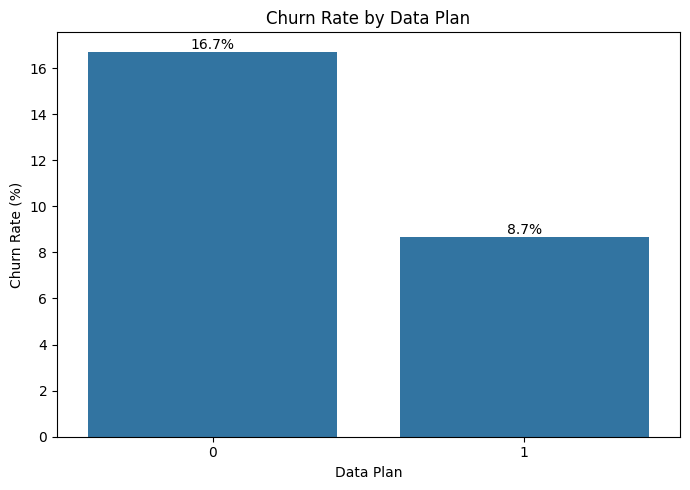

In [ ]:
plt.figure(figsize=(7, 5))

ax = sns.barplot(
    data=data_plan_churn,
    x="DataPlan",
    y="Churn_Rate"
)

plt.title("Churn Rate by Data Plan")
plt.xlabel("Data Plan")
plt.ylabel("Churn Rate (%)")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%"
    )

plt.tight_layout()
plt.show()

Customers without a data plan have a higher observed churn rate than customers with a data plan, with an approximately 8.0 percentage-point difference. This suggests that data-plan status may contain useful information for predicting churn.

In [ ]:
# Customer service calls vs churn

service_churn = (
    df.groupby("CustServCalls")["Churn"]
      .agg(
          Customers="count",
          Churn_Rate="mean"
      )
      .reset_index()
)

service_churn["Churn_Rate"] *= 100

service_churn

,CustServCalls,Customers,Churn_Rate
0,0,697,13.199426
1,1,1181,10.330229
2,2,759,11.462451
3,3,429,10.256410
4,4,166,45.783133
5,5,66,60.606061
6,6,22,63.636364
7,7,9,55.555556
8,8,2,50.000000
9,9,2,100.000000


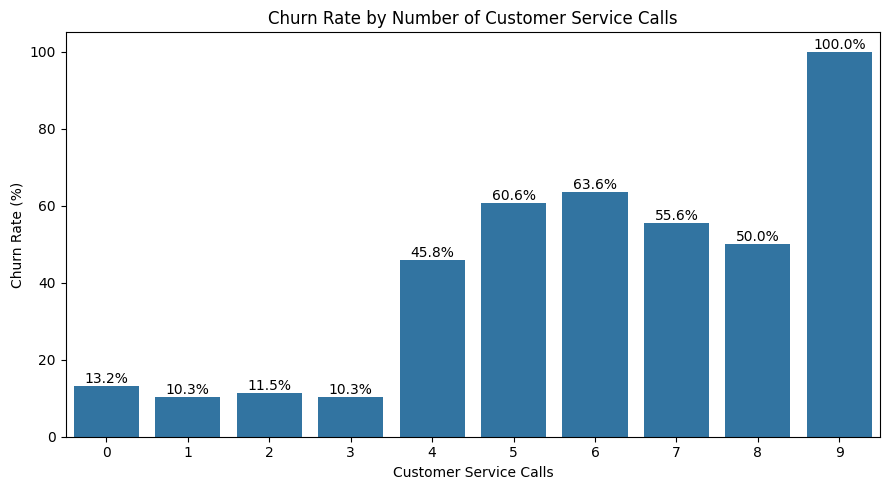

In [ ]:
plt.figure(figsize=(9, 5))

ax = sns.barplot(
    data=service_churn,
    x="CustServCalls",
    y="Churn_Rate"
)

plt.title("Churn Rate by Number of Customer Service Calls")
plt.xlabel("Customer Service Calls")
plt.ylabel("Churn Rate (%)")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%"
    )

plt.tight_layout()
plt.show()

Observed churn is around 10–13% for customers with 0–3 service calls, then rises to 45.8% for 4 calls and 60.6% for 5 calls. The 6–9 call groups are small, so their rates are unstable. These are associations in this dataset, not evidence that service calls cause churn.

In [ ]:
# Numerical variables vs churn

churn_numeric_summary = (
    df.groupby("Churn")[numerical_features]
      .mean()
      .T
)

churn_numeric_summary.columns = [
    "No_Churn",
    "Churn"
]

churn_numeric_summary

,No_Churn,Churn
AccountWeeks,100.793684,102.664596
DataUsage,0.862151,0.546957
CustServCalls,1.449825,2.229814
DayMins,175.175754,206.914079
DayCalls,100.283158,101.335404
MonthlyCharge,55.816246,59.190062
OverageFee,9.954618,10.623085
RoamMins,10.158877,10.700000


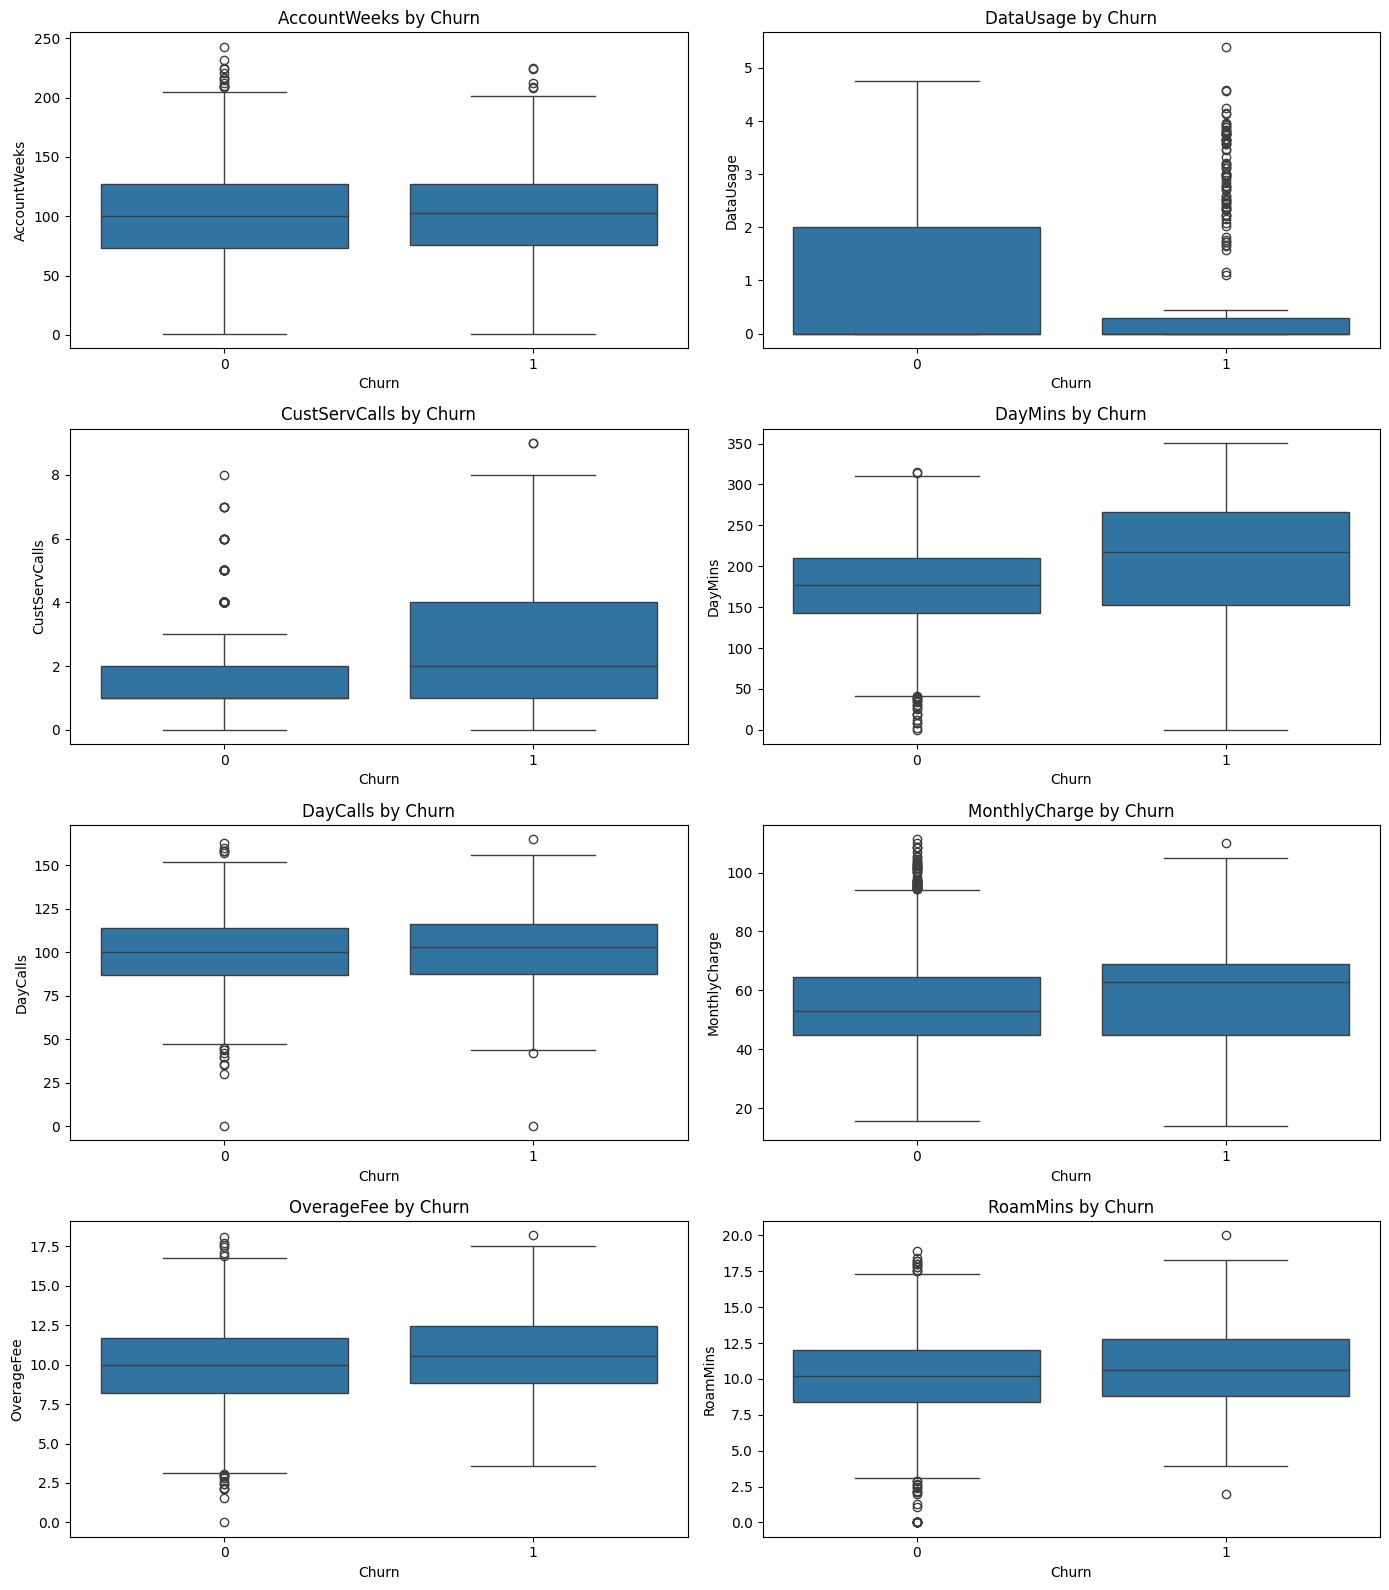

In [ ]:
# Visualize numerical variables by churn

fig, axes = plt.subplots(
    nrows=4,
    ncols=2,
    figsize=(14, 16)
)

for ax, column in zip(axes.flatten(), numerical_features):
    sns.boxplot(
        data=df,
        x="Churn",
        y=column,
        ax=ax
    )

    ax.set_title(f"{column} by Churn")
    ax.set_xlabel("Churn")
    ax.set_ylabel(column)

plt.tight_layout()
plt.show()

In [ ]:
# Correlation analysis

correlation_matrix = df[numerical_features + ["Churn"]].corr()

correlation_matrix

,AccountWeeks,DataUsage,CustServCalls,DayMins,DayCalls,MonthlyCharge,OverageFee,RoamMins,Churn
AccountWeeks,1.000000,0.014391,-0.003796,0.006216,0.038470,0.012581,-0.006749,0.009514,0.016541
DataUsage,0.014391,1.000000,-0.021723,0.003176,-0.007962,0.781660,0.019637,0.162746,-0.087195
CustServCalls,-0.003796,-0.021723,1.000000,-0.013423,-0.018942,-0.028017,-0.012964,-0.009640,0.208750
DayMins,0.006216,0.003176,-0.013423,1.000000,0.006750,0.567968,0.007038,-0.010155,0.205151
DayCalls,0.038470,-0.007962,-0.018942,0.006750,1.000000,-0.007963,-0.021449,0.021565,0.018459
MonthlyCharge,0.012581,0.781660,-0.028017,0.567968,-0.007963,1.000000,0.281766,0.117433,0.072313
OverageFee,-0.006749,0.019637,-0.012964,0.007038,-0.021449,0.281766,1.000000,-0.011023,0.092812
RoamMins,0.009514,0.162746,-0.009640,-0.010155,0.021565,0.117433,-0.011023,1.000000,0.068239
Churn,0.016541,-0.087195,0.208750,0.205151,0.018459,0.072313,0.092812,0.068239,1.000000


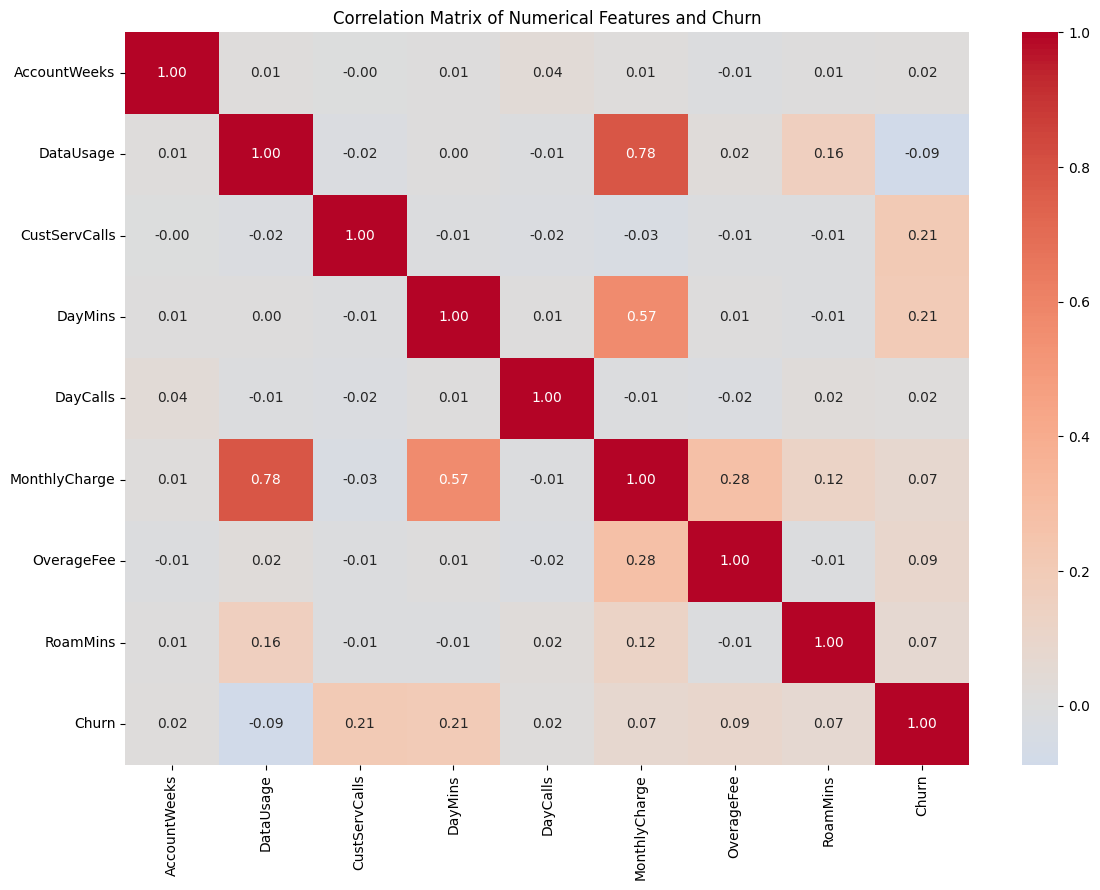

In [ ]:
plt.figure(figsize=(12, 9))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Numerical Features and Churn")
plt.tight_layout()
plt.show()

In [ ]:
correlation_matrix["Churn"].sort_values(ascending=False)


,Churn
Churn,1.000000
CustServCalls,0.208750
DayMins,0.205151
OverageFee,0.092812
MonthlyCharge,0.072313
RoamMins,0.068239
DayCalls,0.018459
AccountWeeks,0.016541
DataUsage,-0.087195


### Correlation with Churn

The correlation analysis shows that `CustServCalls` (r = 0.209) and `DayMins` (r = 0.205) have the strongest positive linear associations with churn among the numerical variables.

`OverageFee`, `MonthlyCharge`, and `RoamMins` show weaker positive associations, while `DataUsage` has a weak negative association with churn. `DayCalls` and `AccountWeeks` have correlations close to zero.

These correlations describe linear associations and should not be interpreted as evidence of causation. Furthermore, a weak individual correlation does not necessarily imply that a feature has no predictive value, because machine-learning models can capture nonlinear relationships and interactions between variables.

The correlation analysis will therefore be used as an exploratory tool rather than as the sole basis for feature selection.

This supports what we saw in the correlation analysis.

Churned customers have, on average, more customer-service calls.

Group comparison asks:

"How do the average characteristics of churned and non-churned customers differ?"

Instead of looking only at averages, let's calculate the median for churned vs non-churned customers.

Why median?

The mean can be influenced by unusually high or low observations.

The median tells us the middle customer in each group.

If the mean and median tell a similar story, our finding is more convincing.


In [ ]:
churn_numeric_median = (
    df.groupby("Churn")[numerical_features]
      .median()
      .T
)

churn_numeric_median.columns = [
    "No_Churn",
    "Churn"
]

churn_numeric_median

,No_Churn,Churn
AccountWeeks,100.00,103.00
DataUsage,0.00,0.00
CustServCalls,1.00,2.00
DayMins,177.20,217.60
DayCalls,100.00,103.00
MonthlyCharge,53.00,63.00
OverageFee,9.98,10.57
RoamMins,10.20,10.60


In [ ]:
# Calculate the percentage difference

mean_comparison = (
    df.groupby("Churn")[numerical_features]
      .mean()
      .T
)

mean_comparison.columns = ["No_Churn", "Churn"]

mean_comparison["Absolute_Difference"] = (
    mean_comparison["Churn"] -
    mean_comparison["No_Churn"]
)

mean_comparison["Percentage_Difference"] = (
    mean_comparison["Absolute_Difference"] /
    mean_comparison["No_Churn"] * 100
)

mean_comparison.round(2)

,No_Churn,Churn,Absolute_Difference,Percentage_Difference
AccountWeeks,100.79,102.66,1.87,1.86
DataUsage,0.86,0.55,-0.32,-36.56
CustServCalls,1.45,2.23,0.78,53.80
DayMins,175.18,206.91,31.74,18.12
DayCalls,100.28,101.34,1.05,1.05
MonthlyCharge,55.82,59.19,3.37,6.04
OverageFee,9.95,10.62,0.67,6.72
RoamMins,10.16,10.70,0.54,5.33


The most noticeable differences are:

- higher CustServCalls
- higher DayMins
- lower DataUsage

among churned customers.

But remember:

Percentage difference is descriptive, not a measure of causal impact.

One important statistical check:

We'll test whether the numerical differences between churned and non-churned groups are statistically distinguishable.

Because these variables may not follow normal distributions, we'll use the Mann–Whitney U test rather than automatically assuming normality.

We're not using the statistical test to decide which features the ML model is allowed to use.

Instead, we're asking:

"Is there evidence that the distributions of these variables differ between the two churn groups?"

These tests are exploratory. Because we test several numerical features, the p-values are not adjusted for multiple comparisons, so interpret them cautiously. A low p-value does not mean the difference is large or useful in practice.

In [ ]:
from scipy.stats import mannwhitneyu

In [ ]:
statistical_results = []

for column in numerical_features:

    no_churn = df.loc[df["Churn"] == 0, column]
    churn = df.loc[df["Churn"] == 1, column]

    statistic, p_value = mannwhitneyu(
        no_churn,
        churn,
        alternative="two-sided"
    )

    statistical_results.append({
        "Feature": column,
        "U_Statistic": statistic,
        "P_Value": p_value
    })

statistical_results = pd.DataFrame(statistical_results)

statistical_results["Significant_At_0.05"] = (
    statistical_results["P_Value"] < 0.05
)

statistical_results.sort_values("P_Value")

,Feature,U_Statistic,P_Value,Significant_At_0.05
3,DayMins,495604.0,6.715053e-23,True
2,CustServCalls,539322.5,3.064025e-15,True
1,DataUsage,793828.0,3.806989e-09,True
5,MonthlyCharge,581431.0,4.660629e-08,True
6,OverageFee,588278.0,3.166600e-07,True
7,RoamMins,619588.0,4.439644e-04,True
4,DayCalls,658577.0,1.288274e-01,False
0,AccountWeeks,670684.5,3.683972e-01,False


**churn rate by binned DayMins**:

Because DayMins has a relatively strong positive association with churn, let's see whether the relationship is actually visible across usage levels.

we're asking:

Does churn actually change across different usage ranges?

In [ ]:
df["DayMins_Band"] = pd.cut(
    df["DayMins"],
    bins=5
)

daymins_churn = (
    df.groupby("DayMins_Band", observed=False)["Churn"]
      .agg(
          Customers="count",
          Churn_Rate="mean"
      )
      .reset_index()
)

daymins_churn["Churn_Rate"] *= 100

daymins_churn

,DayMins_Band,Customers,Churn_Rate
0,"(-0.351, 70.16]",81,12.345679
1,"(70.16, 140.32]",680,12.941176
2,"(140.32, 210.48]",1610,8.198758
3,"(210.48, 280.64]",858,21.445221
4,"(280.64, 350.8]",104,66.346154


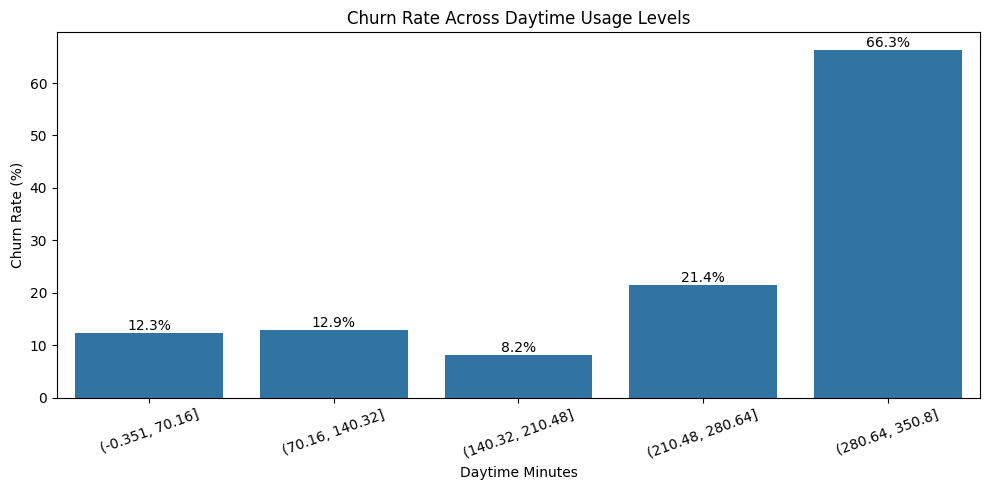

In [ ]:
plt.figure(figsize=(10, 5))

ax = sns.barplot(
    data=daymins_churn,
    x="DayMins_Band",
    y="Churn_Rate"
)

plt.title("Churn Rate Across Daytime Usage Levels")
plt.xlabel("Daytime Minutes")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=20)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%"
    )

plt.tight_layout()
plt.show()

Churn rates vary across daytime-usage bands. Customers in the highest daytime-usage group show substantially higher observed churn than customers in the middle usage ranges. This suggests that the relationship between daytime usage and churn may not be purely linear and supports evaluating models capable of capturing nonlinear relationships.

**churn by customer-service-call bands**:

The 7–9 call groups are too small to interpret individually.

This gives us a more statistically sensible business view than interpreting a group containing only two customers.

Let's create more meaningful groups:

In [ ]:
df["CustServCalls_Band"] = pd.cut(
    df["CustServCalls"],
    bins=[-1, 3, 5, 9],
    labels=[
        "0–3 calls",
        "4–5 calls",
        "6–9 calls"
    ]
)

service_band_churn = (
    df.groupby("CustServCalls_Band", observed=False)["Churn"]
      .agg(
          Customers="count",
          Churn_Rate="mean"
      )
      .reset_index()
)

service_band_churn["Churn_Rate"] *= 100

service_band_churn

,CustServCalls_Band,Customers,Churn_Rate
0,0–3 calls,3066,11.252446
1,4–5 calls,232,50.000000
2,6–9 calls,35,62.857143


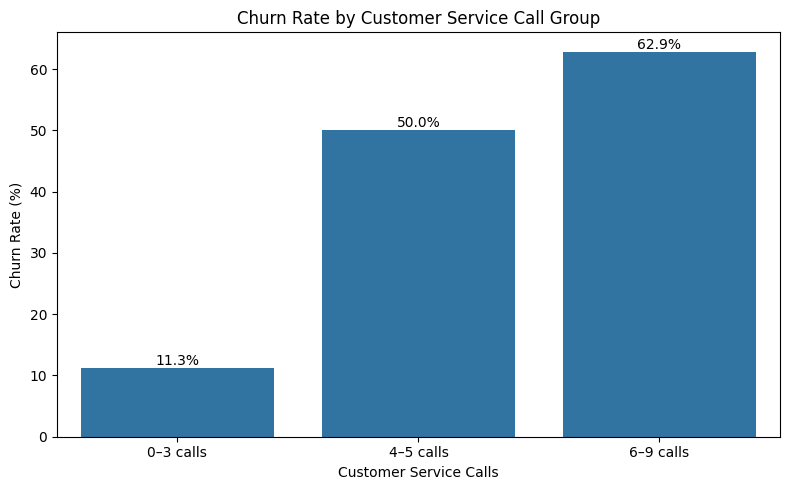

In [ ]:
plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=service_band_churn,
    x="CustServCalls_Band",
    y="Churn_Rate"
)

plt.title("Churn Rate by Customer Service Call Group")
plt.xlabel("Customer Service Calls")
plt.ylabel("Churn Rate (%)")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%"
    )

plt.tight_layout()
plt.show()

A substantial increase in observed churn is present among customers with four or more customer-service calls. The pattern suggests that repeated customer-service interactions may be an important indicator of customer attrition risk. However, the smaller sample size of the 6–9-call group requires caution when generalizing this estimate.

Important cleanup note

We temporarily created:

DayMins_Band
CustServCalls_Band

These are EDA-only variables.

And before we move to modeling, we'll remove them.
This prevents accidental contamination of our modeling dataset.

In [ ]:
df = df.drop(
    columns=["DayMins_Band", "CustServCalls_Band"],
    errors="ignore"
)

print("Temporary EDA columns removed.")

Temporary EDA columns removed.


In [ ]:
# verify:

eda_only_columns = ["DayMins_Band", "CustServCalls_Band"]
remaining_columns = [col for col in eda_only_columns if col in df.columns]

if remaining_columns:
    raise ValueError(f"EDA-only columns remain: {remaining_columns}")

print("Verified: temporary EDA columns are removed.")

Verified: temporary EDA columns are removed.


### Key EDA Findings

1. **Contract renewal is strongly associated with observed churn.**  
   Customers who did not renew their contracts had an observed churn rate of 42.4%, compared with 11.5% among customers who renewed. This represents a difference of approximately 30.9 percentage points.

2. **Data-plan status is associated with churn differences.**  
   Customers without a data plan had an observed churn rate of 16.7%, compared with 8.7% among customers with a data plan.

3. **Repeated customer-service interactions are associated with substantially higher churn.**  
   Customers with 0–3 service calls had an observed churn rate of approximately 11.3%, compared with 50.0% among customers with 4–5 calls and 62.9% among customers with 6–9 calls. The smaller size of the 6–9-call group means this estimate should be interpreted cautiously.

4. **Daytime call usage differs between churn groups.**  
   Churned customers had a higher mean daytime usage (206.91 minutes) than non-churned customers (175.18 minutes), and the difference was statistically distinguishable in the Mann–Whitney U test.

5. **Data usage differs between churn groups.**  
   Churned customers had lower average data usage than non-churned customers. The distributions also differed statistically, although both groups had a median data usage of zero.

6. **Several numerical variables show statistically distinguishable group differences.**  
   DayMins, CustServCalls, DataUsage, MonthlyCharge, OverageFee, and RoamMins showed statistically distinguishable distributions between churned and non-churned customers at the 0.05 significance level. DayCalls and AccountWeeks did not.

7. **Some relationships appear nonlinear.**  
   Churn rates vary considerably across DayMins bands, with particularly high churn in the highest daytime-usage group. This motivates comparing linear and nonlinear machine-learning models.

### EDA Interpretation Caveat

These findings describe associations observed in the dataset and should not be interpreted as evidence of causation. Statistical significance does not necessarily imply practical or predictive importance. Final feature usefulness will be assessed using leakage-safe machine-learning validation and out-of-sample evaluation.

# Modeling Preparation :
(Our goal is to prepare the data without introducing data leakage.)

In [ ]:
# Create X and y again

X = df.drop(columns="Churn")
y = df["Churn"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (3333, 10)
y shape: (3333,)


In [ ]:
# Train/test split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)
print("Training target:", y_train.shape)
print("Test target:", y_test.shape)

Training set: (2666, 10)
Test set: (667, 10)
Training target: (2666,)
Test target: (667,)


**stratify=y?**

**This is particularly important because our target is imbalanced.**

Remember:

No churn → 85.5%

Churn    → 14.5%

stratify=y tries to preserve approximately the same class proportion in both datasets.

So we want something approximately like:

Training:

No churn ≈ 85.5%

Churn    ≈ 14.5%

Test:

No churn ≈ 85.5%

Churn    ≈ 14.5%

**Without stratification, a random split could produce somewhat different proportions.**

In [ ]:
# Verify the split

train_distribution = (
    y_train.value_counts(normalize=True)
    .sort_index()
    .mul(100)
)

test_distribution = (
    y_test.value_counts(normalize=True)
    .sort_index()
    .mul(100)
)

split_check = pd.DataFrame({
    "Train_Percentage": train_distribution,
    "Test_Percentage": test_distribution
})

split_check

,Train_Percentage,Test_Percentage
Churn,,
0,85.52138,85.457271
1,14.47862,14.542729


In [ ]:
# Verify there is no overlap : (This is a nice reproducibility/data-integrity check.)
# Because our dataset doesn't have a unique customer ID, we can compare the indices created by the split:

overlap = set(X_train.index).intersection(set(X_test.index))

print("Number of overlapping rows:", len(overlap))

Number of overlapping rows: 0


This confirms that no original row appears in both sets.

## Train/Test Split

The dataset was divided into training and test sets using an 80/20 split with `random_state=42` for reproducibility.

Stratified sampling was used to preserve the class distribution of the imbalanced target variable across both sets.

 The test split was used to compare initial models, so it is not an untouched final test set. Cross-validation was used for subsequent model tuning. I report the test-set results as exploratory.

# Dummy Baseline Model

Because the churn target is imbalanced, a majority-class baseline is established before training machine-learning models.

The baseline always predicts the majority class (`No Churn`). This provides a reference point for determining whether the machine-learning models provide meaningful predictive value beyond simply predicting the most common class.

In [ ]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

dummy_model = DummyClassifier(
    strategy="most_frequent"
)

dummy_model.fit(X_train, y_train)

dummy_pred = dummy_model.predict(X_test)
dummy_prob = dummy_model.predict_proba(X_test)[:, 1]

In [ ]:
# Evaluate the baseline

dummy_metrics = {
    "Accuracy": accuracy_score(y_test, dummy_pred),
    "Precision": precision_score(y_test, dummy_pred, zero_division=0),
    "Recall": recall_score(y_test, dummy_pred, zero_division=0),
    "F1": f1_score(y_test, dummy_pred, zero_division=0),
    "ROC_AUC": roc_auc_score(y_test, dummy_prob),
    "PR_AUC": average_precision_score(y_test, dummy_prob)
}

pd.DataFrame(
    dummy_metrics.items(),
    columns=["Metric", "Score"]
)

,Metric,Score
0,Accuracy,0.854573
1,Precision,0.000000
2,Recall,0.000000
3,F1,0.000000
4,ROC_AUC,0.500000
5,PR_AUC,0.145427


In [ ]:
# Confusion matrix

cm_dummy = confusion_matrix(y_test, dummy_pred)

cm_dummy

array([[570,   0],
       [ 97,   0]])

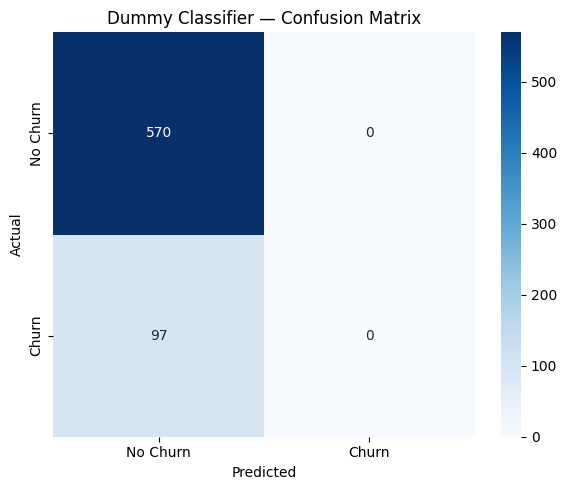

In [ ]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_dummy,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

plt.title("Dummy Classifier — Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()

The key problem is obvious:

The baseline completely fails to identify churners.

We can eventually say:

"Because only approximately 14.5% of customers churned, accuracy alone was insufficient. A majority-class baseline achieved approximately 85.5% accuracy while detecting none of the churned customers. Therefore, model evaluation emphasized recall, F1-score, ROC-AUC, and PR-AUC rather than accuracy alone."


**Decide the primary business metric**

Now we need to think about the actual business problem.

**Telecom Customer Attrition Prediction**

Suppose the telecom company uses the model to identify customers who might churn.

**There are two kinds of mistakes**:

**False Negative**

Customer will churn:

Actual = Churn

Prediction = No Churn

The company misses an at-risk customer.

**False Positive**

Customer won't churn:
Actual = No Churn
Prediction = Churn

The company may unnecessarily target that customer with a retention offer.
These have different business costs.

Therefore we'll evaluate several metrics together:

Metric -->                	Why we'll use it

Accuracy	--        Overall reference only

Precision	--        How many predicted churners actually churn

Recall	--           How many actual churners we identify

F1	--              Balance between precision and recall

ROC-AUC	--          Ranking/discrimination ability

PR-AUC	--          Especially informative with an imbalanced positive class


Metric plan for this project
PR-AUC (average precision) is the primary metric for model comparison and tuning because churn is the minority class. F1 is used to choose a provisional decision threshold that balances precision and recall. I’ll also report precision, recall, ROC-AUC, and accuracy for context.
The dataset does not provide retention-offer costs or campaign capacity, so this threshold is not claimed to be optimal for a real business decision.

## Baseline Results — Interpretation

The majority-class Dummy Classifier achieved 85.46% accuracy by predicting every customer as `No Churn`. However, it achieved 0% precision, 0% recall, and an F1-score of 0 for the churn class because it failed to identify any churned customers.

The ROC-AUC of 0.50 indicates no discrimination beyond random ranking, while the PR-AUC of approximately 0.145 is consistent with the churn prevalence in the test set.

This demonstrates why accuracy alone is not an appropriate primary metric for this imbalanced churn-prediction problem. Subsequent models will be evaluated using recall, precision, F1-score, ROC-AUC, and PR-AUC, with particular attention to the model's ability to identify actual churners.

Most importantly, we'll put scaling and the model inside a Pipeline.

**Why use a Pipeline?** :

It guarantees that:

The scaler learns its parameters from the training data only.

Then the same transformation is applied to the test data.

This helps prevent preprocessing leakage.

# Build Logistic Regression pipeline:
## Logistic Regression

Logistic Regression is used as the first predictive model because it provides an interpretable and computationally efficient baseline for binary classification.

Standardization is included in a scikit-learn Pipeline so that scaling parameters are learned exclusively from the training data. This prevents information from the test set from influencing preprocessing.

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

logistic_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

logistic_pipeline.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('model', LogisticRegression(max_iter=1000, random_state=42))])

**Generate predictions**:

We need two different outputs:

Class prediction

0 → No Churn
1 → Churn

Probability

For example:

Customer A → 0.08
Customer B → 0.72
Customer C → 0.41

The probability is extremely important because later we can adjust the classification threshold.

In [ ]:
logistic_pred = logistic_pipeline.predict(X_test)

logistic_prob = logistic_pipeline.predict_proba(X_test)[:, 1]

In [ ]:
# Evaluate Logistic Regression

logistic_metrics = {
    "Accuracy": accuracy_score(y_test, logistic_pred),
    "Precision": precision_score(
        y_test,
        logistic_pred,
        zero_division=0
    ),
    "Recall": recall_score(
        y_test,
        logistic_pred,
        zero_division=0
    ),
    "F1": f1_score(
        y_test,
        logistic_pred,
        zero_division=0
    ),
    "ROC_AUC": roc_auc_score(
        y_test,
        logistic_prob
    ),
    "PR_AUC": average_precision_score(
        y_test,
        logistic_prob
    )
}

logistic_metrics

{'Accuracy': 0.8575712143928036,
 'Precision': 0.5263157894736842,
 'Recall': 0.20618556701030927,
 'F1': 0.2962962962962963,
 'ROC_AUC': np.float64(0.8091155724362452),
 'PR_AUC': np.float64(0.41649128008757)}

In [ ]:
# display

logistic_metrics_df = pd.DataFrame(
    logistic_metrics.items(),
    columns=["Metric", "Score"]
)

logistic_metrics_df

,Metric,Score
0,Accuracy,0.857571
1,Precision,0.526316
2,Recall,0.206186
3,F1,0.296296
4,ROC_AUC,0.809116
5,PR_AUC,0.416491


In [ ]:
# Classification report

print(
    classification_report(
        y_test,
        logistic_pred,
        target_names=["No Churn", "Churn"],
        zero_division=0
    )
)

              precision    recall  f1-score   support

    No Churn       0.88      0.97      0.92       570
       Churn       0.53      0.21      0.30        97

    accuracy                           0.86       667
   macro avg       0.70      0.59      0.61       667
weighted avg       0.83      0.86      0.83       667



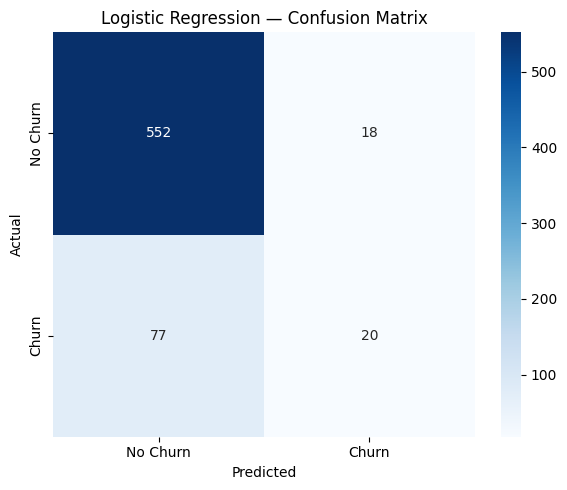

In [ ]:
# Confusion matrix

cm_logistic = confusion_matrix(
    y_test,
    logistic_pred
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_logistic,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

plt.title("Logistic Regression — Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()

**Inspect Logistic Regression coefficients**:

One advantage of Logistic Regression is interpretability.

Because we used a pipeline, we can retrieve the model:

This tells us which standardized features have the largest coefficient magnitudes.

In [ ]:
logistic_model = logistic_pipeline.named_steps["model"]

coefficients = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": logistic_model.coef_[0]
})

coefficients["Absolute_Coefficient"] = (
    coefficients["Coefficient"].abs()
)

coefficients = coefficients.sort_values(
    "Absolute_Coefficient",
    ascending=False
)

coefficients

,Feature,Coefficient,Absolute_Coefficient
4,CustServCalls,0.729021,0.729021
2,DataPlan,-0.665027,0.665027
1,ContractRenewal,-0.579097,0.579097
5,DayMins,0.468209,0.468209
7,MonthlyCharge,0.331216,0.331216
8,OverageFee,0.275850,0.275850
9,RoamMins,0.210402,0.210402
6,DayCalls,0.082490,0.082490
0,AccountWeeks,0.034709,0.034709
3,DataUsage,-0.007387,0.007387


In [ ]:
# coefficient table

coefficients[
    ["Feature", "Coefficient"]
].round(4)

,Feature,Coefficient
4,CustServCalls,0.7290
2,DataPlan,-0.6650
1,ContractRenewal,-0.5791
5,DayMins,0.4682
7,MonthlyCharge,0.3312
8,OverageFee,0.2758
9,RoamMins,0.2104
6,DayCalls,0.0825
0,AccountWeeks,0.0347
3,DataUsage,-0.0074


The Logistic Regression model achieved an accuracy of **85.76%**, precision of **52.63%**, recall of **20.62%**, and F1-score of **29.63%** on the held-out test set. Its **ROC-AUC of 0.8091** indicates that the model has meaningful ability to distinguish between customers who churn and those who do not. The **PR-AUC of 0.4165** is also substantially higher than the majority-class baseline PR-AUC of **0.1454**, indicating improved performance in identifying the minority churn class.

Although the overall accuracy is only slightly higher than the Dummy Classifier baseline (85.46%), the Logistic Regression model provides substantially more useful churn predictions. Unlike the Dummy Classifier, which identified none of the churned customers, Logistic Regression achieved a churn recall of **20.62%** and a churn precision of **52.63%**. However, the model still missed a large proportion of actual churners at the default classification threshold of 0.5. Therefore, its current performance should be considered a baseline rather than the final churn-prediction solution.

The standardized coefficients provide useful model-level interpretability. `CustServCalls` has the largest positive coefficient (**0.7290**), indicating a positive modeled association with churn after accounting for the other variables. `DayMins`, `MonthlyCharge`, `OverageFee`, and `RoamMins` also have positive coefficients. In contrast, `DataPlan` (**-0.6650**) and `ContractRenewal` (**-0.5791**) have negative coefficients, indicating lower modeled churn odds when these binary indicators are equal to 1, holding the other features constant.

Overall, Logistic Regression shows that the available features contain signal for classifying the dataset’s supplied Churn label. At the default 0.50 threshold, churn recall remains low, so model comparison and threshold analysis are still needed. The dataset documentation does not establish when these features were recorded relative to churn; therefore, this result alone does not show that the model can predict future churn or improve retention.

> **Important:** These coefficients represent associations learned by the model and should not be interpreted as evidence that a feature causes customer churn.

# Random Forest

Random Forest is introduced as a nonlinear tree-based model. It can capture nonlinear relationships and interactions between customer characteristics without requiring feature scaling.

The model will be evaluated using the same test set and metrics used for the baseline and Logistic Regression to ensure a fair comparison.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=42)

In [ ]:
# Generate Random Forest predictions

rf_pred = rf_model.predict(X_test)

rf_prob = rf_model.predict_proba(X_test)[:, 1]

In [ ]:
# Evaluate Random Forest

rf_metrics = {
    "Accuracy": accuracy_score(
        y_test,
        rf_pred
    ),
    "Precision": precision_score(
        y_test,
        rf_pred,
        zero_division=0
    ),
    "Recall": recall_score(
        y_test,
        rf_pred,
        zero_division=0
    ),
    "F1": f1_score(
        y_test,
        rf_pred,
        zero_division=0
    ),
    "ROC_AUC": roc_auc_score(
        y_test,
        rf_prob
    ),
    "PR_AUC": average_precision_score(
        y_test,
        rf_prob
    )
}

rf_metrics_df = pd.DataFrame(
    rf_metrics.items(),
    columns=["Metric", "Score"]
)

rf_metrics_df

,Metric,Score
0,Accuracy,0.928036
1,Precision,0.818182
2,Recall,0.649485
3,F1,0.724138
4,ROC_AUC,0.857560
5,PR_AUC,0.740709


In [ ]:
# Classification report

print(
    classification_report(
        y_test,
        rf_pred,
        target_names=["No Churn", "Churn"],
        zero_division=0
    )
)

              precision    recall  f1-score   support

    No Churn       0.94      0.98      0.96       570
       Churn       0.82      0.65      0.72        97

    accuracy                           0.93       667
   macro avg       0.88      0.81      0.84       667
weighted avg       0.92      0.93      0.92       667



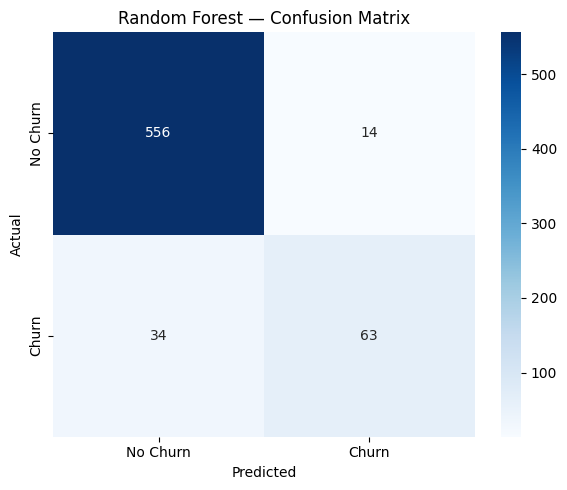

In [ ]:
# Confusion matrix

cm_rf = confusion_matrix(
    y_test,
    rf_pred
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

plt.title("Random Forest — Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()

In [ ]:
# Compare all models

model_comparison = pd.DataFrame({
    "Dummy": dummy_metrics,
    "Logistic_Regression": logistic_metrics,
    "Random_Forest": rf_metrics
}).T

model_comparison.round(4)

,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
Dummy,0.8546,0.0000,0.0000,0.0000,0.5000,0.1454
Logistic_Regression,0.8576,0.5263,0.2062,0.2963,0.8091,0.4165
Random_Forest,0.9280,0.8182,0.6495,0.7241,0.8576,0.7407


In [ ]:
# Random Forest feature importance

rf_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(
    "Importance",
    ascending=False
)

rf_importance

,Feature,Importance
5,DayMins,0.202584
7,MonthlyCharge,0.166665
4,CustServCalls,0.144993
8,OverageFee,0.094938
9,RoamMins,0.084379
3,DataUsage,0.078116
1,ContractRenewal,0.069556
6,DayCalls,0.062248
0,AccountWeeks,0.061135
2,DataPlan,0.035387


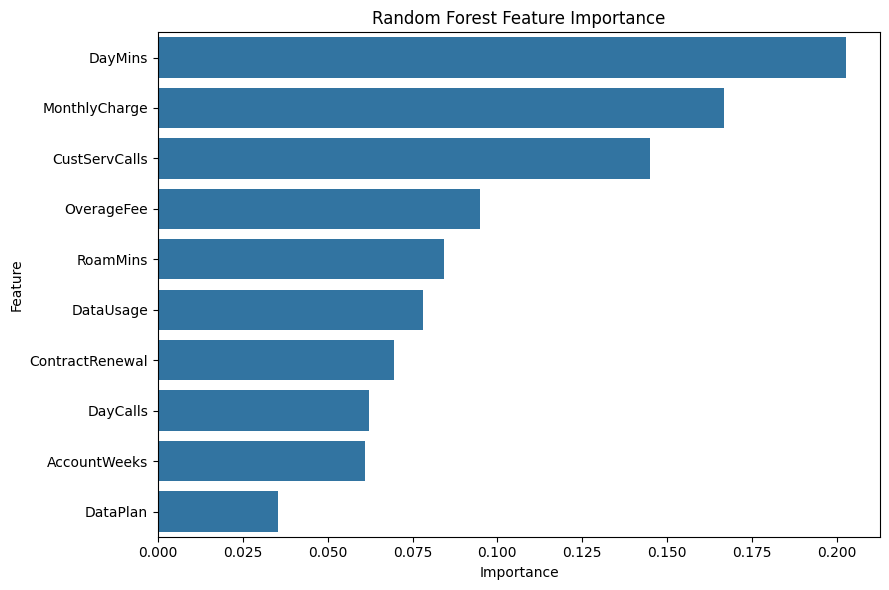

In [ ]:
plt.figure(figsize=(9, 6))

sns.barplot(
    data=rf_importance,
    x="Importance",
    y="Feature"
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

**Random Forest — Overall Interpretation**

The Random Forest model substantially improves upon both the Dummy Classifier and Logistic Regression on the held-out test set. It achieved an accuracy of **92.80%**, precision of **81.82%**, recall of **64.95%**, and F1-score of **72.41%** for the churn class. The model also achieved a **ROC-AUC of 0.8576** and a **PR-AUC of 0.7407**, indicating strong discriminatory performance and substantially improved identification of the minority churn class.

The most important improvement is the churn recall. Logistic Regression identified approximately **20.62%** of actual churners at the default 0.5 classification threshold, whereas Random Forest identified approximately **64.95%**. This indicates that the nonlinear tree-based model is capturing predictive patterns that are not fully represented by the linear Logistic Regression model.

The Random Forest feature-importance results show that `DayMins` (**0.2026**), `MonthlyCharge` (**0.1667**), and `CustServCalls` (**0.1450**) are the three highest-ranked features according to the model's impurity-based feature importance. `OverageFee`, `RoamMins`, and `DataUsage` also contribute to the model's predictions.

The feature-importance ranking should be interpreted as a measure of the features' contribution to the Random Forest's predictive splits, rather than as evidence of causation. It also should not be directly compared with Logistic Regression coefficients because the two measures represent different concepts of model interpretation.

Overall, the Random Forest provides substantially stronger predictive performance than the initial Logistic Regression baseline on this test set. However, this result is based on a single train/test split. Cross-validation and hyperparameter tuning will be used later to assess whether the performance is robust before selecting a final model.

**Logistic Regression coefficients describe the direction and strength of the model's linear relationship after standardization.**

**Random Forest feature importance describes how much features contributed to reducing impurity across the trees.**

# XGBoost

XGBoost is a gradient-boosting algorithm. It builds trees sequentially, with each new tree fitted to reduce errors from the model built so far. This allows it to capture nonlinear relationships and interactions between features.

In [ ]:
import xgboost as xgb

print("XGBoost version:", xgb.__version__)

XGBoost version: 3.4.1


In [ ]:
# class imbalance

negative_count = (y_train == 0).sum()
positive_count = (y_train == 1).sum()

scale_pos_weight = negative_count / positive_count

print("Negative samples:", negative_count)
print("Positive samples:", positive_count)
print("scale_pos_weight:", scale_pos_weight)

Negative samples: 2280
Positive samples: 386
scale_pos_weight: 5.9067357512953365


**XGBoost — Initial Model**

XGBoost is introduced as a gradient-boosting model to evaluate whether sequentially constructed decision trees can capture additional nonlinear relationships and interactions beyond the Logistic Regression and Random Forest models.

Because the churn class is substantially smaller than the non-churn class, `scale_pos_weight` is calculated from the training data and used to give additional weight to the minority class.

This is an initial benchmark configuration rather than the final tuned model. Hyperparameter optimization and cross-validation will be performed later.

In [ ]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1,
    eval_metric="logloss"
)

xgb_model.fit(
    X_train,
    y_train
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=-1,
              num_parallel_tree=None, ...)

n_estimators=300 → number of boosting trees

learning_rate=0.05 → relatively gradual learning

max_depth=4 → limits tree complexity

subsample=0.8 → uses 80% of rows per boosting iteration

colsample_bytree=0.8 → uses 80% of features

scale_pos_weight → accounts for class imbalance

random_state=42 → reproducibility

These are initial benchmark settings, not claims that these are the optimal values.

In [ ]:
# Generate XGBoost predictions

xgb_pred = xgb_model.predict(X_test)

xgb_prob = xgb_model.predict_proba(X_test)[:, 1]

In [ ]:
# Evaluate XGBoost

xgb_metrics = {
    "Accuracy": accuracy_score(
        y_test,
        xgb_pred
    ),
    "Precision": precision_score(
        y_test,
        xgb_pred,
        zero_division=0
    ),
    "Recall": recall_score(
        y_test,
        xgb_pred,
        zero_division=0
    ),
    "F1": f1_score(
        y_test,
        xgb_pred,
        zero_division=0
    ),
    "ROC_AUC": roc_auc_score(
        y_test,
        xgb_prob
    ),
    "PR_AUC": average_precision_score(
        y_test,
        xgb_prob
    )
}

xgb_metrics_df = pd.DataFrame(
    xgb_metrics.items(),
    columns=["Metric", "Score"]
)

xgb_metrics_df

,Metric,Score
0,Accuracy,0.889055
1,Precision,0.605505
2,Recall,0.680412
3,F1,0.640777
4,ROC_AUC,0.848182
5,PR_AUC,0.723026


In [ ]:
# Classification report

print(
    classification_report(
        y_test,
        xgb_pred,
        target_names=["No Churn", "Churn"],
        zero_division=0
    )
)

              precision    recall  f1-score   support

    No Churn       0.94      0.92      0.93       570
       Churn       0.61      0.68      0.64        97

    accuracy                           0.89       667
   macro avg       0.77      0.80      0.79       667
weighted avg       0.90      0.89      0.89       667



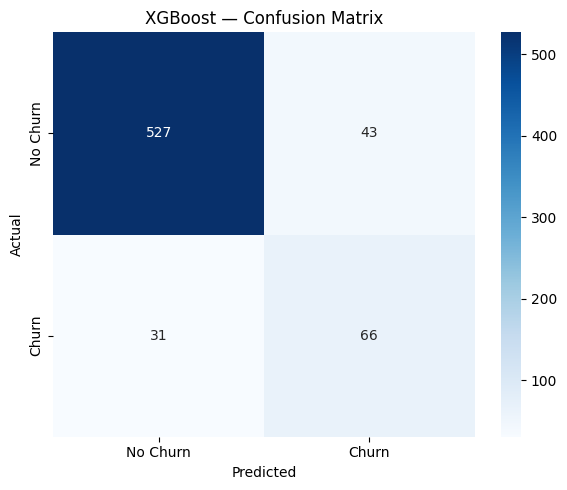

In [ ]:
# Confusion matrix

cm_xgb = confusion_matrix(
    y_test,
    xgb_pred
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_xgb,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

plt.title("XGBoost — Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()

In [ ]:
# Update the model comparison

model_comparison = pd.DataFrame({
    "Dummy": dummy_metrics,
    "Logistic_Regression": logistic_metrics,
    "Random_Forest": rf_metrics,
    "XGBoost": xgb_metrics
}).T

model_comparison.round(4)

,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
Dummy,0.8546,0.0000,0.0000,0.0000,0.5000,0.1454
Logistic_Regression,0.8576,0.5263,0.2062,0.2963,0.8091,0.4165
Random_Forest,0.9280,0.8182,0.6495,0.7241,0.8576,0.7407
XGBoost,0.8891,0.6055,0.6804,0.6408,0.8482,0.7230


**XGBoost — Overall Interpretation**

The initial XGBoost model achieved an accuracy of **88.91%**, precision of **60.55%**, recall of **68.04%**, and F1-score of **64.08%** for the churn class on the held-out test set. The model achieved a **ROC-AUC of 0.8482** and a **PR-AUC of 0.7230**, demonstrating substantially stronger predictive performance than the Dummy Classifier baseline.

XGBoost identified approximately **68.04% of the actual churners**, which is slightly higher than the **64.95% recall achieved by the initial Random Forest model**. However, Random Forest achieved higher precision (**81.82% vs. 60.55%**), F1-score (**72.41% vs. 64.08%**), ROC-AUC (**0.8576 vs. 0.8482**), and PR-AUC (**0.7407 vs. 0.7230**) on this particular test split.

This comparison indicates a trade-off between the two tree-based models. The initial XGBoost configuration identifies a slightly larger proportion of actual churners, while Random Forest produces fewer false-positive churn predictions and shows stronger overall performance across several evaluation metrics.

The XGBoost results should not yet be treated as the final model selection. Both models were evaluated using initial configurations on a single held-out test set. Cross-validation and hyperparameter tuning will be performed to assess model stability and determine whether the observed differences persist across multiple training-validation splits.

The results also demonstrate why model selection should not be based on accuracy alone. Because customer churn is an imbalanced classification problem, **precision, recall, F1-score, ROC-AUC, and PR-AUC** provide additional information about the model's ability to identify the minority churn class.

> **Important:** Model performance represents predictive association rather than causation. Features identified as important by tree-based models should not be interpreted as factors that independently cause customer churn.

**Cross-Validation**:

Initial model performance was evaluated on a single held-out test set. To assess whether model performance is stable across different subsets of the training data, stratified 5-fold cross-validation will be used.

Stratification is important because the churn class is a minority class. Each fold will therefore maintain approximately the same class distribution.

The test set will remain untouched during cross-validation and hyperparameter tuning. It will only be used for final model evaluation.

In [ ]:
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [ ]:
# Create the three models again

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# 1. Logistic Regression
logistic_cv_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

# 2. Random Forest
rf_cv_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

# 3. XGBoost
xgb_cv_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1,
    eval_metric="logloss"
)

**Why recreate the models?**

Because cross-validation should train a fresh model inside each fold.

We don't want to reuse the models already fitted on the entire training set.

In [ ]:
# Define the evaluation metrics

from sklearn.model_selection import cross_validate

scoring = {
    "ROC_AUC": "roc_auc",
    "PR_AUC": "average_precision",
    "Recall": "recall",
    "Precision": "precision",
    "F1": "f1"
}

In [ ]:
# Run cross-validation for Logistic Regression

logistic_cv_results = cross_validate(
    logistic_cv_model,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

logistic_cv_results

{'fit_time': array([0.0183537 , 0.01775312, 0.01434112, 0.01613307, 0.01287127]),
 'score_time': array([0.02679706, 0.02537012, 0.02436447, 0.02501607, 0.02273345]),
 'test_ROC_AUC': array([0.80108525, 0.82273866, 0.808527  , 0.82233994, 0.81584643]),
 'test_PR_AUC': array([0.40589732, 0.44982729, 0.45017873, 0.46362042, 0.48210033]),
 'test_Recall': array([0.16666667, 0.24675325, 0.1038961 , 0.19480519, 0.20779221]),
 'test_Precision': array([0.54166667, 0.5       , 0.53333333, 0.57692308, 0.51612903]),
 'test_F1': array([0.25490196, 0.33043478, 0.17391304, 0.29126214, 0.2962963 ])}

In [ ]:
# Run Random Forest cross-validation

rf_cv_results = cross_validate(
    rf_cv_model,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

rf_cv_results

{'fit_time': array([2.66628718, 2.63817739, 3.82741261, 3.84637117, 1.52413154]),
 'score_time': array([0.24486041, 0.23931479, 0.3296864 , 0.3339231 , 0.20005131]),
 'test_ROC_AUC': array([0.92653509, 0.90261164, 0.9044771 , 0.90672704, 0.90675553]),
 'test_PR_AUC': array([0.82444228, 0.82736028, 0.7969322 , 0.79731893, 0.80650293]),
 'test_Recall': array([0.70512821, 0.75324675, 0.62337662, 0.63636364, 0.61038961]),
 'test_Precision': array([0.88709677, 0.86567164, 0.85714286, 0.84482759, 0.90384615]),
 'test_F1': array([0.78571429, 0.80555556, 0.72180451, 0.72592593, 0.72868217])}

In [ ]:
# Run XGBoost cross-validation

xgb_cv_results = cross_validate(
    xgb_cv_model,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

xgb_cv_results

{'fit_time': array([0.31426048, 0.31281114, 0.33982706, 0.34346318, 0.19267011]),
 'score_time': array([0.035887  , 0.03660035, 0.03383517, 0.03475189, 0.02269459]),
 'test_ROC_AUC': array([0.89788574, 0.90766689, 0.90704033, 0.902455  , 0.88935407]),
 'test_PR_AUC': array([0.7851317 , 0.83625557, 0.8039817 , 0.74898778, 0.79537301]),
 'test_Recall': array([0.75641026, 0.84415584, 0.75324675, 0.71428571, 0.7012987 ]),
 'test_Precision': array([0.64835165, 0.67010309, 0.74358974, 0.6547619 , 0.76056338]),
 'test_F1': array([0.69822485, 0.74712644, 0.7483871 , 0.68322981, 0.72972973])}

**The mean tells us the average performance.**

**The standard deviation tells us how much performance varies across folds.**

In [ ]:
# Create a reusable function

import numpy as np
import pandas as pd

def summarize_cv_results(cv_results, model_name):
    summary = {}

    metrics = [
        "ROC_AUC",
        "PR_AUC",
        "Recall",
        "Precision",
        "F1"
    ]

    for metric in metrics:
        values = cv_results[f"test_{metric}"]

        summary[f"{metric}_Mean"] = values.mean()
        summary[f"{metric}_Std"] = values.std()

    summary["Model"] = model_name

    return summary

In [ ]:
logistic_summary = summarize_cv_results(
    logistic_cv_results,
    "Logistic Regression"
)

rf_summary = summarize_cv_results(
    rf_cv_results,
    "Random Forest"
)

xgb_summary = summarize_cv_results(
    xgb_cv_results,
    "XGBoost"
)

In [ ]:
# Combine the results

cv_summary = pd.DataFrame([
    logistic_summary,
    rf_summary,
    xgb_summary
])

cv_summary = cv_summary[
    [
        "Model",
        "ROC_AUC_Mean",
        "ROC_AUC_Std",
        "PR_AUC_Mean",
        "PR_AUC_Std",
        "Recall_Mean",
        "Recall_Std",
        "Precision_Mean",
        "Precision_Std",
        "F1_Mean",
        "F1_Std"
    ]
]

cv_summary.round(4)

,Model,ROC_AUC_Mean,ROC_AUC_Std,PR_AUC_Mean,PR_AUC_Std,Recall_Mean,Recall_Std,Precision_Mean,Precision_Std,F1_Mean,F1_Std
0,Logistic Regression,0.8141,0.0083,0.4503,0.0251,0.1840,0.0476,0.5336,0.0260,0.2694,0.0534
1,Random Forest,0.9094,0.0087,0.8105,0.0131,0.6657,0.0546,0.8717,0.0212,0.7535,0.0350
2,XGBoost,0.9009,0.0068,0.7939,0.0283,0.7539,0.0500,0.6955,0.0471,0.7213,0.0263


In [ ]:
# Check fold-by-fold performance

def fold_results_dataframe(cv_results, model_name):
    return pd.DataFrame({
        "Model": model_name,
        "Fold": range(1, len(cv_results["test_ROC_AUC"]) + 1),
        "ROC_AUC": cv_results["test_ROC_AUC"],
        "PR_AUC": cv_results["test_PR_AUC"],
        "Recall": cv_results["test_Recall"],
        "Precision": cv_results["test_Precision"],
        "F1": cv_results["test_F1"]
    })

In [ ]:
logistic_folds = fold_results_dataframe(
    logistic_cv_results,
    "Logistic Regression"
)

rf_folds = fold_results_dataframe(
    rf_cv_results,
    "Random Forest"
)

xgb_folds = fold_results_dataframe(
    xgb_cv_results,
    "XGBoost"
)

In [ ]:
# Combine them:

all_fold_results = pd.concat(
    [
        logistic_folds,
        rf_folds,
        xgb_folds
    ],
    ignore_index=True
)

all_fold_results.round(4)

,Model,Fold,ROC_AUC,PR_AUC,Recall,Precision,F1
0,Logistic Regression,1,0.8011,0.4059,0.1667,0.5417,0.2549
1,Logistic Regression,2,0.8227,0.4498,0.2468,0.5000,0.3304
2,Logistic Regression,3,0.8085,0.4502,0.1039,0.5333,0.1739
3,Logistic Regression,4,0.8223,0.4636,0.1948,0.5769,0.2913
4,Logistic Regression,5,0.8158,0.4821,0.2078,0.5161,0.2963
5,Random Forest,1,0.9265,0.8244,0.7051,0.8871,0.7857
6,Random Forest,2,0.9026,0.8274,0.7532,0.8657,0.8056
7,Random Forest,3,0.9045,0.7969,0.6234,0.8571,0.7218
8,Random Forest,4,0.9067,0.7973,0.6364,0.8448,0.7259
9,Random Forest,5,0.9068,0.8065,0.6104,0.9038,0.7287


### Cross-Validation — Overall Interpretation

Five-fold stratified cross-validation provides a more robust assessment of model performance than relying on a single train/test split.

The cross-validation results show that the tree-based models substantially outperform Logistic Regression. Logistic Regression achieved a mean ROC-AUC of **0.8141**, mean PR-AUC of **0.4503**, mean recall of **0.1840**, and mean F1-score of **0.2694**.

Random Forest achieved a mean ROC-AUC of **0.9094**, mean PR-AUC of **0.8105**, mean recall of **0.6657**, mean precision of **0.8717**, and mean F1-score of **0.7535**. These results indicate strong and relatively consistent predictive performance across the five validation folds.

XGBoost achieved a mean ROC-AUC of **0.9009**, mean PR-AUC of **0.7939**, and the highest mean recall of **0.7539**. Its mean precision was **0.6955**, resulting in an F1-score of **0.7213**. Therefore, XGBoost identified a larger proportion of actual churners on average, while Random Forest provided a stronger balance between identifying churners and limiting false-positive churn predictions.

The relatively small standard deviations across the folds indicate that the models' performance was reasonably stable across different training and validation subsets.

These results should not yet be treated as the final model selection. Hyperparameter tuning will be performed using the training data and cross-validation. The held-out test set will remain untouched until the final evaluation stage.

In [ ]:
# Create a visualization of CV performance
# Let's compare the mean metrics.

cv_plot_data = cv_summary.melt(
    id_vars="Model",
    value_vars=[
        "ROC_AUC_Mean",
        "PR_AUC_Mean",
        "Recall_Mean",
        "Precision_Mean",
        "F1_Mean"
    ],
    var_name="Metric",
    value_name="Score"
)

cv_plot_data["Metric"] = (
    cv_plot_data["Metric"]
    .str.replace("_Mean", "", regex=False)
)

cv_plot_data


,Model,Metric,Score
0,Logistic Regression,ROC_AUC,0.814107
1,Random Forest,ROC_AUC,0.909421
2,XGBoost,ROC_AUC,0.900880
3,Logistic Regression,PR_AUC,0.450325
4,Random Forest,PR_AUC,0.810511
5,XGBoost,PR_AUC,0.793946
6,Logistic Regression,Recall,0.183983
7,Random Forest,Recall,0.665701
8,XGBoost,Recall,0.753879
9,Logistic Regression,Precision,0.533610


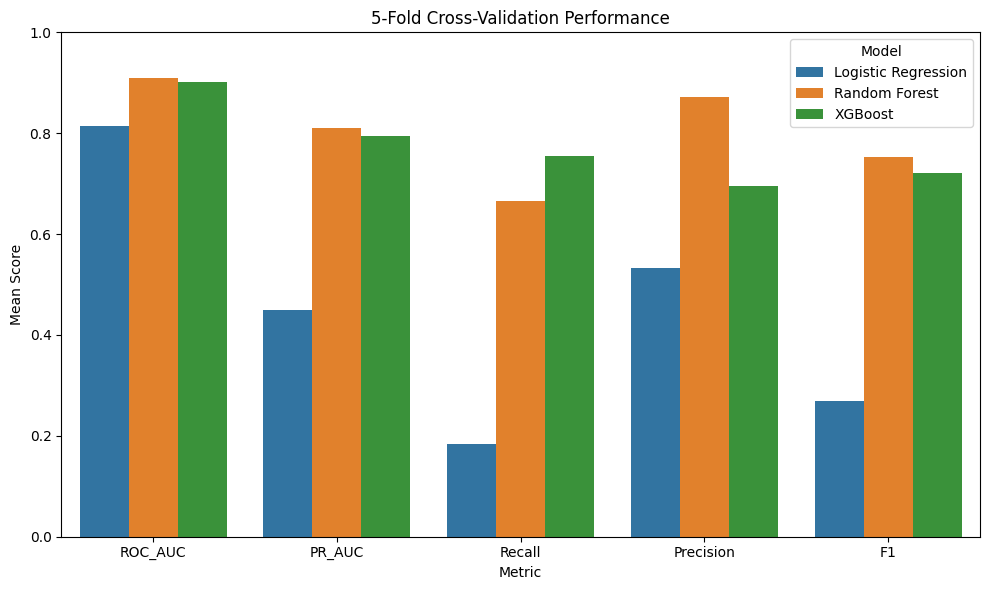

In [ ]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=cv_plot_data,
    x="Metric",
    y="Score",
    hue="Model"
)

plt.title("5-Fold Cross-Validation Performance")
plt.xlabel("Metric")
plt.ylabel("Mean Score")
plt.ylim(0, 1)

plt.legend(title="Model")
plt.tight_layout()
plt.show()

**Tune Random Forest**
### **Hyperparameter Tuning**

Random Forest and XGBoost showed substantially stronger cross-validation performance than Logistic Regression. Hyperparameter tuning will therefore focus on these two nonlinear models.

RandomizedSearchCV will be used to explore a controlled range of hyperparameter combinations using stratified cross-validation.

The primary optimization metric is PR-AUC (Average Precision) because customer churn is the minority class. ROC-AUC, recall, precision, and F1-score will also be retained for comparison.

The held-out test set will remain untouched throughout hyperparameter tuning.

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

rf_param_dist = {
    "n_estimators": randint(200, 600),
    "max_depth": [None, 5, 8, 12, 16, 20],
    "min_samples_split": randint(2, 15),
    "min_samples_leaf": randint(1, 8),
    "max_features": ["sqrt", "log2", None],
    "class_weight": [None, "balanced"]
}

rf_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ),
    param_distributions=rf_param_dist,
    n_iter=30,
    scoring="average_precision",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    refit=True
)

rf_search.fit(X_train, y_train)

RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=RandomForestClassifier(n_jobs=-1, random_state=42),
                   n_iter=30, n_jobs=-1,
                   param_distributions={'class_weight': [None, 'balanced'],
                                        'max_depth': [None, 5, 8, 12, 16, 20],
                                        'max_features': ['sqrt', 'log2', None],
                                        'min_samples_leaf': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7b28d8b02210>,
                                        'min_samples_split': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7b28d8b01f90>,
                                        'n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7b28d8d5e900>},
                   random_state=42, scoring='average_precision')

In [ ]:
print("Best Random Forest PR-AUC:", rf_search.best_score_)
print("\nBest parameters:")
print(rf_search.best_params_)

Best Random Forest PR-AUC: 0.8197172629661326

Best parameters:
{'class_weight': None, 'max_depth': 8, 'max_features': 'sqrt', 'min_samples_leaf': 3, 'min_samples_split': 6, 'n_estimators': 330}


In [ ]:
rf_best_model = rf_search.best_estimator_

In [ ]:
# Tune XGBoost

from scipy.stats import randint, uniform

xgb_param_dist = {
    "n_estimators": randint(200, 600),
    "learning_rate": uniform(0.02, 0.13),
    "max_depth": randint(2, 8),
    "min_child_weight": randint(1, 8),
    "subsample": uniform(0.7, 0.3),
    "colsample_bytree": uniform(0.7, 0.3),
    "gamma": uniform(0, 0.5)
}

xgb_search = RandomizedSearchCV(
    estimator=XGBClassifier(
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        n_jobs=-1,
        eval_metric="logloss"
    ),
    param_distributions=xgb_param_dist,
    n_iter=30,
    scoring="average_precision",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    refit=True
)

xgb_search.fit(X_train, y_train)

RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=True,
                                           eval_metric='logloss',
                                           feature_types=None,
                                           feature_weights=None, gamma=None,...
                                        'max_depth': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7b28d8cba2c0>,
                                        'min_child_weight': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7b28db02fbf0>,
                                        'n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7b28d8cba060>,
                                        'subsample': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7b28d8b02990>},
                   random_state=42, scoring='average_precision')

In [ ]:
print("Best XGBoost PR-AUC:", xgb_search.best_score_)
print("\nBest parameters:")
print(xgb_search.best_params_)

Best XGBoost PR-AUC: 0.8011199929174667

Best parameters:
{'colsample_bytree': np.float64(0.9266653415629146), 'gamma': np.float64(0.11439908274581123), 'learning_rate': np.float64(0.03000738827774309), 'max_depth': 4, 'min_child_weight': 3, 'n_estimators': 285, 'subsample': np.float64(0.9641403517045772)}


In [ ]:
xgb_best_model = xgb_search.best_estimator_

In [ ]:
# Compare tuned models

tuned_cv_results = pd.DataFrame({
    "Model": [
        "Tuned Random Forest",
        "Tuned XGBoost"
    ],
    "CV_PR_AUC": [
        rf_search.best_score_,
        xgb_search.best_score_
    ]
})

tuned_cv_results.round(4)

,Model,CV_PR_AUC
0,Tuned Random Forest,0.8197
1,Tuned XGBoost,0.8011


**Threshold Analysis**

Both Random Forest and XGBoost currently use:

Probability >= 0.50 → Churn

Probability <  0.50 → No Churn

But 0.50 is simply the default classification threshold.

For churn prediction, different thresholds produce different:
- Recall
- Precision
- F1

**Generate validation probabilities**:

We need probabilities generated from the training data using cross-validation.

cross_val_predict leaves each observation out when fitting its fold model. However, the Random Forest and XGBoost hyperparameters were selected using cross-validation across all training rows. So these predictions are out-of-fold for model fitting, but not independent of hyperparameter selection. Treat the threshold results as guidance for model development, not as an unbiased performance estimate. Nested cross-validation would provide a stronger evaluation.

In [ ]:
from sklearn.model_selection import cross_val_predict

rf_cv_prob = cross_val_predict(
    rf_best_model,
    X_train,
    y_train,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

xgb_cv_prob = cross_val_predict(
    xgb_best_model,
    X_train,
    y_train,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

In [ ]:
# Calculate threshold metrics

import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

def threshold_analysis(y_true, probabilities):
    thresholds = np.arange(0.05, 0.96, 0.05)

    results = []

    for threshold in thresholds:
        predictions = (
            probabilities >= threshold
        ).astype(int)

        results.append({
            "Threshold": threshold,
            "Precision": precision_score(
                y_true,
                predictions,
                zero_division=0
            ),
            "Recall": recall_score(
                y_true,
                predictions,
                zero_division=0
            ),
            "F1": f1_score(
                y_true,
                predictions,
                zero_division=0
            )
        })

    return pd.DataFrame(results)

In [ ]:
rf_threshold_results = threshold_analysis(
    y_train,
    rf_cv_prob
)

xgb_threshold_results = threshold_analysis(
    y_train,
    xgb_cv_prob
)

In [ ]:
# Display:

rf_threshold_results.round(4)

,Threshold,Precision,Recall,F1
0,0.05,0.3449,0.9016,0.4989
1,0.10,0.4891,0.8705,0.6263
2,0.15,0.5591,0.8575,0.6769
3,0.20,0.6248,0.8238,0.7106
4,0.25,0.6778,0.7902,0.7297
5,0.30,0.7244,0.7694,0.7462
6,0.35,0.7922,0.7409,0.7657
7,0.40,0.8466,0.7150,0.7753
8,0.45,0.8656,0.6839,0.7641
9,0.50,0.8989,0.6451,0.7511


In [ ]:
xgb_threshold_results.round(4)

,Threshold,Precision,Recall,F1
0,0.05,0.1664,0.9741,0.2843
1,0.10,0.2399,0.9197,0.3805
2,0.15,0.3404,0.8782,0.4906
3,0.20,0.4379,0.8497,0.5780
4,0.25,0.5000,0.8420,0.6274
5,0.30,0.5441,0.8316,0.6578
6,0.35,0.5735,0.8187,0.6745
7,0.40,0.6012,0.8083,0.6895
8,0.45,0.6286,0.7850,0.6982
9,0.50,0.6622,0.7668,0.7107


In [ ]:
# Find the best threshold:

rf_best_threshold_row = rf_threshold_results.loc[
    rf_threshold_results["F1"].idxmax()
]

xgb_best_threshold_row = xgb_threshold_results.loc[
    xgb_threshold_results["F1"].idxmax()
]

print("Random Forest:")
print(rf_best_threshold_row)

print("\nXGBoost:")
print(xgb_best_threshold_row)

Random Forest:
Threshold    0.400000
Precision    0.846626
Recall       0.715026
F1           0.775281
Name: 7, dtype: float64

XGBoost:
Threshold    0.750000
Precision    0.822630
Recall       0.696891
F1           0.754558
Name: 14, dtype: float64


## Threshold Analysis — Interpretation

The threshold was selected by maximizing F1 across the tested range of 0.05 to 0.95:

- **Random Forest:** threshold 0.40; precision 0.8466, recall 0.7150, F1 0.7753.
- **XGBoost:** threshold 0.75; precision 0.8226, recall 0.6969, F1 0.7546.

F1 is a provisional way to balance precision and recall because the dataset does not provide retention-offer costs or campaign capacity. These thresholds are development choices, not business-optimal decisions.

The predictions are out-of-fold for model fitting, but the hyperparameters were selected using cross-validation across the training data. Treat these threshold results as exploratory, not independent performance estimates. The test set was also used for initial model comparisons, so its results are exploratory too.

Changing the threshold changes the predicted class labels, not the model’s underlying probabilities.

In [ ]:
print("Random Forest best CV PR-AUC:")
print(rf_search.best_score_)

print("\nRandom Forest best parameters:")
print(rf_search.best_params_)

print("\nXGBoost best CV PR-AUC:")
print(xgb_search.best_score_)

print("\nXGBoost best parameters:")
print(xgb_search.best_params_)

Random Forest best CV PR-AUC:
0.8197172629661326

Random Forest best parameters:
{'class_weight': None, 'max_depth': 8, 'max_features': 'sqrt', 'min_samples_leaf': 3, 'min_samples_split': 6, 'n_estimators': 330}

XGBoost best CV PR-AUC:
0.8011199929174667

XGBoost best parameters:
{'colsample_bytree': np.float64(0.9266653415629146), 'gamma': np.float64(0.11439908274581123), 'learning_rate': np.float64(0.03000738827774309), 'max_depth': 4, 'min_child_weight': 3, 'n_estimators': 285, 'subsample': np.float64(0.9641403517045772)}


In [ ]:
final_model_comparison = pd.DataFrame({
    "Model": [
        "Tuned Random Forest",
        "Tuned XGBoost"
    ],
    "CV_PR_AUC": [
        rf_search.best_score_,
        xgb_search.best_score_
    ],
    "Selected_Threshold": [
        rf_best_threshold_row["Threshold"],
        xgb_best_threshold_row["Threshold"]
    ],
    "Threshold_Precision": [
        rf_best_threshold_row["Precision"],
        xgb_best_threshold_row["Precision"]
    ],
    "Threshold_Recall": [
        rf_best_threshold_row["Recall"],
        xgb_best_threshold_row["Recall"]
    ],
    "Threshold_F1": [
        rf_best_threshold_row["F1"],
        xgb_best_threshold_row["F1"]
    ]
})

final_model_comparison.round(4)

,Model,CV_PR_AUC,Selected_Threshold,Threshold_Precision,Threshold_Recall,Threshold_F1
0,Tuned Random Forest,0.8197,0.40,0.8466,0.7150,0.7753
1,Tuned XGBoost,0.8011,0.75,0.8226,0.6969,0.7546


# Final Model Selection

Hyperparameter tuning was performed for Random Forest and XGBoost using stratified five-fold cross-validation, with PR-AUC as the primary optimization metric.

The tuned Random Forest achieved a cross-validation PR-AUC of **0.8197**, compared with **0.8011** for tuned XGBoost.

Threshold analysis showed a trade-off between precision and recall. At its selected threshold of 0.40, Random Forest achieved precision of 0.8466, recall of 0.7150, and F1-score of 0.7753. At its selected threshold of 0.75, XGBoost achieved precision of 0.8226, recall of 0.6969, and F1-score of 0.7546.

Based on the combination of cross-validation PR-AUC, precision, recall, and F1-score, the tuned Random Forest was selected as the final model for the held-out test evaluation.

The selected decision threshold is **0.40**, determined using validation predictions from the training data.

In [ ]:
# Record the final model

final_model = rf_best_model
final_threshold = float(rf_best_threshold_row["Threshold"])

print("Final Model: Tuned Random Forest")
print("Final Threshold:", final_threshold)

Final Model: Tuned Random Forest
Final Threshold: 0.4


In [ ]:
# Final Test Evaluation

# Generate final test probabilities

final_test_prob = final_model.predict_proba(X_test)[:, 1]

final_test_pred = (
    final_test_prob >= final_threshold
).astype(int)

In [ ]:
print("Number of test observations:", len(y_test))
print("Predicted churn:", final_test_pred.sum())
print("Actual churn:", y_test.sum())

Number of test observations: 667
Predicted churn: 83
Actual churn: 97


In [ ]:
# Calculate final metrics

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

In [ ]:
final_accuracy = accuracy_score(
    y_test,
    final_test_pred
)

final_precision = precision_score(
    y_test,
    final_test_pred,
    zero_division=0
)

final_recall = recall_score(
    y_test,
    final_test_pred,
    zero_division=0
)

final_f1 = f1_score(
    y_test,
    final_test_pred,
    zero_division=0
)

final_roc_auc = roc_auc_score(
    y_test,
    final_test_prob
)

final_pr_auc = average_precision_score(
    y_test,
    final_test_prob
)

In [ ]:
# results table:

final_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC_AUC",
        "PR_AUC"
    ],
    "Score": [
        final_accuracy,
        final_precision,
        final_recall,
        final_f1,
        final_roc_auc,
        final_pr_auc
    ]
})

final_results.round(4)

,Metric,Score
0,Accuracy,0.9220
1,Precision,0.7711
2,Recall,0.6598
3,F1,0.7111
4,ROC_AUC,0.8638
5,PR_AUC,0.7454


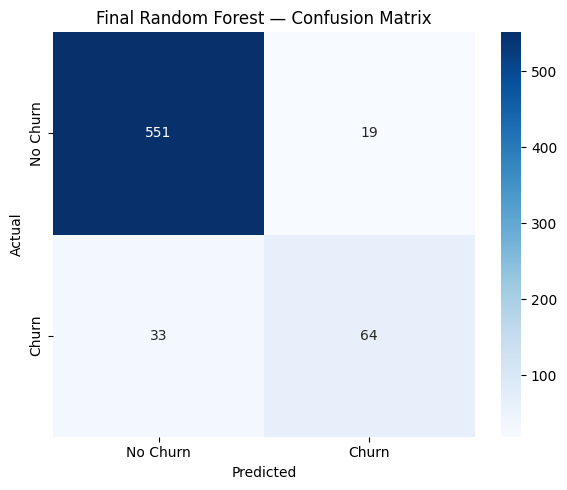

In [ ]:
import os

# Final confusion matrix

cm_final = confusion_matrix(
    y_test,
    final_test_pred
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_final,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

plt.title("Final Random Forest — Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()

# Create the directory if it does not exist

FIGURES_DIR = PROJECT_ROOT / "outputs" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

plt.savefig(
    FIGURES_DIR / "final_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
# Final classification report

print(
    classification_report(
        y_test,
        final_test_pred,
        target_names=["No Churn", "Churn"],
        zero_division=0
    )
)

              precision    recall  f1-score   support

    No Churn       0.94      0.97      0.95       570
       Churn       0.77      0.66      0.71        97

    accuracy                           0.92       667
   macro avg       0.86      0.81      0.83       667
weighted avg       0.92      0.92      0.92       667



In [ ]:
# Save the final metrics

OUTPUT_DIR = PROJECT_ROOT / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

final_results.round(4).to_csv(
    OUTPUT_DIR / "final_model_results.csv",
    index=False
)

print("Final model results saved.")


Final model results saved.


In [ ]:
# Final Model Interpretation
# Because Random Forest is our final model:

final_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": final_model.feature_importances_
}).sort_values(
    "Importance",
    ascending=False
)

final_importance.round(4)

,Feature,Importance
5,DayMins,0.2319
7,MonthlyCharge,0.1784
4,CustServCalls,0.1754
1,ContractRenewal,0.0907
3,DataUsage,0.0821
8,OverageFee,0.0701
9,RoamMins,0.0613
2,DataPlan,0.0494
6,DayCalls,0.0324
0,AccountWeeks,0.0283


In [ ]:
# Save it:

final_importance.round(4).to_csv(
     OUTPUT_DIR / "final_feature_importance.csv",
    index=False
)

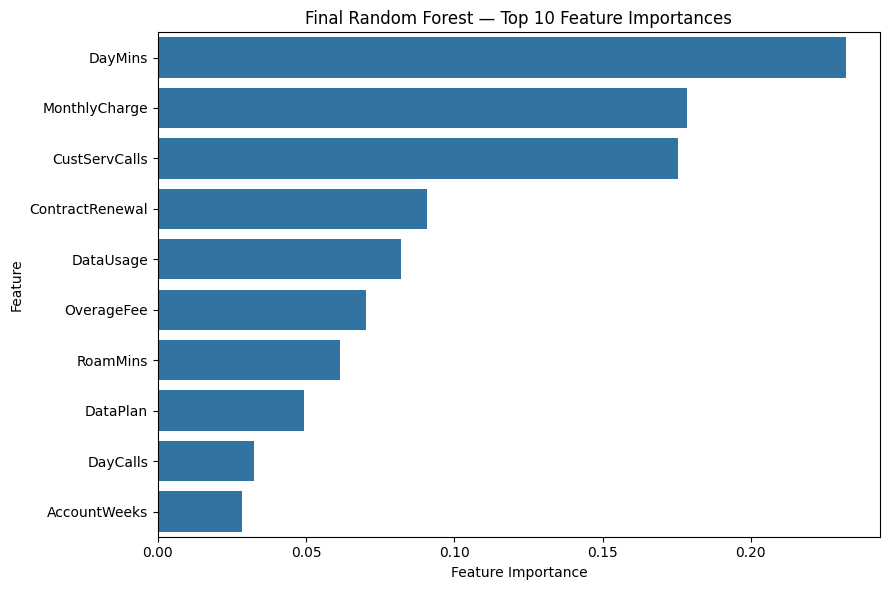

In [ ]:
# Visualize feature importance

top_features = final_importance.head(10)

plt.figure(figsize=(9, 6))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Final Random Forest — Top 10 Feature Importances")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.tight_layout()

plt.savefig(
  FIGURES_DIR / "final_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Business Recommendations & Insights

On the existing test split, the tuned Random Forest achieved 92.20% accuracy, 77.11% precision, 65.98% recall, 71.11% F1-score, 86.38% ROC-AUC, and 74.54% PR-AUC. The split was used in initial model comparisons, so these are exploratory results, not an untouched final estimate.
At a threshold of 0.40, the model identified 64 of the 97 customers with the supplied churn label and missed 33. Of the 83 customers it flagged, 64 had that label, giving 77.11% precision. The dataset documentation does not establish when the features were recorded relative to churn, so these results do not demonstrate future churn prediction or show that a retention offer would prevent churn. They could motivate a pilot after validation on future data and measurement of intervention outcomes.

## Key Business Insights

### 1. Prioritize high-risk customers
Use predicted churn probabilities to prioritize customers for retention review instead of applying the same intervention to the entire customer base.

### 2. Investigate high-usage customers
`DayMins` was the most important feature in the final Random Forest model (importance = 0.2319). Churned customers also showed higher average daily minutes in the exploratory analysis. High-usage customers can therefore be reviewed for plan suitability, pricing, and service experience.

### 3. Review customers with higher monthly charges
`MonthlyCharge` was the second-most important predictive feature (importance = 0.1784). Churned customers had a higher average monthly charge than non-churned customers. The business could investigate whether high-risk customers are experiencing plan-fit or pricing concerns.

### 4. Strengthen customer-service recovery
`CustServCalls` was the third-most important feature (importance = 0.1754). Exploratory analysis showed substantially higher churn rates among customers with repeated customer-service interactions. Customers with recurring support issues can be prioritized for proactive service recovery.

### 5. Strengthen contract-renewal engagement
Contract renewal status showed a substantial difference in observed churn rates. Customers approaching renewal can be proactively contacted for plan reviews, service checks, and appropriate retention engagement.

### 6. Monitor overage exposure
`OverageFee` contributed to the model's predictions and was higher on average among churned customers. Usage alerts and plan recommendations could help customers avoid unexpected or unsuitable charges.

## Proposed Workflow for Future Validation

Customer Data
→ Model Score
→ Risk Prioritization
→ Customer/Issue Review
→ Targeted Retention Action
→ Outcome Monitoring

## Important Limitation

Feature importance represents predictive contribution within the Random Forest model and should not be interpreted as causal evidence. The identified relationships should be treated as signals for further business investigation rather than proof that individual factors directly cause customer churn.

## Limitations and Next Steps

The dataset documentation does not specify when the features were measured or the churn horizon. This project therefore classifies the supplied `Churn` label; it does not establish an early-warning system for future churn.

The test split was used in initial model comparisons, so its scores are exploratory. The dataset also lacks retention-offer costs, campaign capacity, and intervention outcomes. The 0.40 threshold is an F1-based provisional choice, not a business-optimal decision.

Future work should validate on time-stamped customer data with a defined prediction window, assess probability calibration if scores will be used as probabilities, set thresholds using business costs and capacity, and measure retention outcomes.